# Libraries

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
# Add benchmarking dir so helpers.plot is importable
_bench = Path.cwd().parents[3]
sys.path.insert(0, str(_bench))
from helpers.plot import plot_grouped_bar_by_columns, plot_single_bar_metric, plot_rank_comparison, plot_multi_rank_comparison


# Evaluating COMMONOBJECTSBENCH Benchmarks 

Here we will evaluate the raw query metrics returned by Commonobjectsbench-private. These raw metrics were calculated using [Commonobjectsbench-private](https://huggingface.co/datasets/sagecontinuum/Commonobjectsbench-private) with the original [CLIP](https://huggingface.co/openai/clip-vit-base-patch32) model released by OpenAI, no captioning model, and set to **response_limit=25**. This means it will return up to 25 images. This was configured this way to match production deployment.
>NOTE: This notebook can also be used with the raw query metrics returned by [Commonobjectsbench](https://huggingface.co/datasets/sagecontinuum/Commonobjectsbench), the public version of the benchmark.

To better understand the results, each image is matched with a query in the dataset. Although not all matched images are relevant to the query.

This version creates a baseline for image search with `openai/clip-vit-base-patch32` to be able to compare results with other models and components:

- **NO Caption Generation**: Caption generation was disabled. This was done to be able to compare versions of the system with caption generation enabled. This is important to show that caption generation is helping the system.
- **Vector Search**: Utilizes embeddings of just the images to perform semantic search on **CLIP's** imbedding space. Meaning both the images and their captions are NOT used, only the images are used.
- **NO Keyword Search**: Searches were NOT performed using keywords extracted from image captions. No caption generation so no caption to do keyword search on.
- **NO Hybrid Search**: This version will just do vector search, so NO combination of vector and keyword searches to return the most relevant results.
- **[ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) for Reranker**: A model that refines the order of search results, ensuring that the most relevant documents or items are ranked higher. It goes beyond the initial retrieval step, considering additional factors such as semantic similarity, context, and other relevant features.

Here were the Hyperparameters used for the image search:

In [2]:
#show config values
df = pd.read_csv('config_values.csv')
df

,Config Variable,Value,Type
0,DATASET_PRIVATE,sagecontinuum/CommonObjectsBench-private,str
1,DATASET_PUBLIC,sagecontinuum/CommonObjectsBench,str
2,advanced_query_parameters,"{'alpha': 1.0, 'query_properties': ['caption']...",dict
3,caption_model_name,gemma,str
4,caption_model_prompt,\nrole:\nYou are a world-class Scientific Imag...,str
5,commonobjectsbench_dataset,sagecontinuum/CommonObjectsBench-private,str
6,embed_caption,False,bool
7,embed_image,True,bool
8,enable_bm25,False,bool
9,enable_caption_generation,False,bool


## Query and Image Collection Process

This explanation was grabbed from the [dataset card](https://huggingface.co/datasets/sagecontinuum/Commonobjectsbench-private) in huggingface so that we can better understand the results in further sections.
>NOTE: If you don't have access to the private version of the dataset, you can see the [dataset card](https://huggingface.co/datasets/sagecontinuum/Commonobjectsbench) for the public version of the benchmark. The only difference is that the public version does not have sensitive imagery.

### Query Collection

Queries in CommonObjectsBench are **natural-language descriptions of common objects and everyday scenes**, written to reflect how users might search for general object and scene imagery. They are not manually authored by humans; instead they are **generated by an AI text model (OpenAI, GPT-5-mini) from seed images**.

**Process:**

1. **Seed images** — A fixed number of seed images (controlled by the query-plan hyperparameters) are selected from the candidate image pool.
2. **Query generation** — For each seed, the text API is given the image (and any associated context) and is prompted to produce a natural-language query that someone might use to find that kind of object or scene. The model generates queries describing common objects and scenes so the queries reflect realistic search intents.
3. **One query per seed** — Each generated query is assigned a unique `query_id` (e.g. `query_001`, `query_002`) and is then used to retrieve and label candidate images.

The result is a set of **general-purpose queries** over common object and scene imagery that support evaluation of text-to-image retrieval, relevance classification, and multimodal similarity. For full pipeline details and hyperparameters, see the [dataset card](https://huggingface.co/datasets/sagecontinuum/CommonObjectsBench) and the `config_values.csv` in the benchmark's `summary/` directory.


### Image Annotation

CommonObjectsBench annotates images in two main ways: **vision-based description** of each image, and **relevance labeling** for each query–image pair. Both are automated with AI models (OpenAI APIs), not human annotators.

**1. Vision annotation (per image)**  
Each image is processed with **OpenAI's vision API (GPT-5-mini)** to produce:

- **Summary** — A short factual description (≤30 words).
- **Categorical facets** — From fixed taxonomies: `viewpoint` (e.g. eye_level, overhead, close_up, street_view, top_down, oblique, side_view), `lighting` (e.g. day, night, dusk, indoor, bright, mixed), `environment_type` (e.g. indoor, outdoor, urban, rural, residential, commercial, natural, park, beach), and boolean facets such as `multiple_objects`, `artificial_lighting`, `occlusion_present`, `text_visible`, `person_present`, `animal_present`, `food_present`, `urban_scene`, `rural_scene`, `outdoor_scene`, `vehicle_present`.
- **Controlled vocabulary tags** — Typically 12–18 tags per image from a controlled tag vocabulary.
- **Confidence scores** — For each categorical facet, a score between 0 and 1 (stored in the `confidence` dict).

**2. Relevance labeling (per query–image pair)**  
For each query, candidate images are scored as **relevant (1)** or **not relevant (0)** by an **AI judge** using OpenAI's text API (GPT-5-mini), prompted to reflect whether the image matches the query description. This yields the binary `relevance_label` used for retrieval metrics.

**3. CLIPScore (per query–image pair)**  
A **CLIP similarity score** between the query text and the image is computed offline using the model `apple/DFN5B-CLIP-ViT-H-14-378` and stored in the dataset as `clip_score`.

For annotation prompts and hyperparameters, see the [dataset card](https://huggingface.co/datasets/sagecontinuum/CommonObjectsBench) and the benchmark's `summary/config_values.csv`.


### Query Categories

CommonObjectsBench does not assign each query to a single category. Instead, **queries are characterized by the same metadata dimensions used for images**, so that retrieval can be analyzed (and evaluated) along object- and scene-relevant axes. Each query–image pair has metadata from these **locked taxonomies** (defined in the dataset creation config):

- **viewpoint** — How the scene was captured (e.g. `eye_level`, `overhead`, `close_up`, `distant`, `street_view`, `top_down`, `oblique`, `side_view`, `first_person`, `skyward`, `other`, `unknown`).
- **lighting** — Conditions (e.g. `day`, `night`, `dusk`, `indoor`, `shadow`, `bright`, `backlit`, `mixed`, `other`, `unknown`).
- **environment_type** — Type of environment (e.g. `indoor`, `outdoor`, `urban`, `suburban`, `rural`, `residential`, `commercial`, `industrial`, `recreational`, `natural`, `park`, `beach`, `other`, `unknown`).
- **multiple_objects**, **artificial_lighting**, **occlusion_present**, **text_visible**, **person_present**, **animal_present**, **food_present**, **urban_scene**, **rural_scene**, **outdoor_scene**, **vehicle_present** — Boolean facets per image.

Queries therefore span **diverse objects and scenes** (e.g. people, vehicles, food, animals, indoor/outdoor settings) and **varied conditions** (lighting, viewpoint, environment), so the benchmark can measure both recall of relevant imagery and robustness across metadata dimensions. For the exact taxonomy values, see the [dataset card](https://huggingface.co/datasets/sagecontinuum/CommonObjectsBench) and the benchmark's `summary/config_values.csv`.

### Data Split
The dataset only has a train split. Users can split the dataset as they see fit.

## Query Coverage

Queries cover a range of topics and taxonomies:

![Image Sample](https://huggingface.co/datasets/sagecontinuum/Commonobjectsbench/resolve/main/summary/random_image_sample.png)
![Query Coverage](https://huggingface.co/datasets/sagecontinuum/Commonobjectsbench/resolve/main/summary/image_proportion_donuts.png)
>NOTE: Here we show the image sample and query coverage for the public version of the benchmark since the private version has sensitive imagery.

## Exploratory Data Analysis

The dataset provides an EDA of the data. If you are interested in finding out more analytical information about the data, please refer to it.

[Commonobjectsbench-private EDA](https://huggingface.co/datasets/sagecontinuum/CommonObjectsBench-private/blob/main/summary/CommonObjectBench_eda_analysis.ipynb)
>NOTE: The EDA can be used along side these evaluation metrics to better understand the results.

## Query Metric Dataset

Each row in the dataframe is evaluating a query used in our image search system:
- **query_id**: an ID given to each unique query in the dataset
- **query**: The query inserted into our image search. These are the same queries from the CommonObjectsBench dataset.
- **total_images**: The total images returned from our image search using the specified query.
- **correctly_returned**: The number of images returned that matched with the query indicated in the dataset. For example, if the query was "apple" for the image in the dataset and I used the query "apple" in our image search system, the image returned would be marked as correctly returned since the queries matched.
- **incorrectly_returned**: The number of images returned that did NOT match with the query in the dataset. Using the example above, if we used the query "banana" in our image search system and the image returned had a query of "apple" in the dataset, then it would be marked as incorrectly returned.
- **relevant_images**: The number of images returned marked as relevant. Each image in the dataset is marked as relevant or nonrelevant to the query it is matched with.
- **non_relevant_images**: The number of images returned marked as nonrelevant. Each image in the dataset is marked as relevant or nonrelevant to the query it is matched with.
- **accuracy**: The number of images correctly returned compared to the total images.
- **precision**: The number of relevant images returned compared to the total images.
- **recall**: The number of relevant images returned compared to the number of relevant images in the dataset.
- **hit**: 1 if at least one relevant image was returned. Take the average of this metric to get the hit rate, which is the percentage of queries that had at least one relevant image returned in the top k images (k = response limit).
- **diversity**: The diversity of the returned images. Measures how diverse (non-redundant) the top-k list is based on the cosine similarity of the retrieved item vectors. ILS (Intra-List Similarity) is the average pairwise cosine similarity of the retrieved item vectors; diversity = 1 − ILS, so a higher diversity score is more diverse.
- **NDCG**: A metric used to evaluate a rerank model. A higher score means relevant images were given a higher score than nonrelevant images.
- **clip_NDCG**: NDCG was also calculated for the CLIP scores given in the dataset. This column can be used as a comparison to the column NDCG. CLIP (DFN5B-CLIP-ViT-H-14-378) was used to provide a rerank score for each image. If NDCG is higher than this column, that means our image search system is doing better.
- **rr**: The reciprocal rank of the rerank scores given in the dataset. Take the average of this metric to get the mean reciprocal rank (MRR). This column can be used as a comparison to the column clip_rr.
- **clip_rr**: The reciprocal rank of the CLIP scores given in the dataset. Take the average of this metric to get the mean reciprocal rank. This column can be used as a comparison to the column rr. CLIP DFN5B-CLIP-ViT-H-14-378 was used to provide a rerank score for each image. If rr is higher than this column, that means our image search system is doing better.

The following columns are metadata of the **seed image** (the original image the query was generated from), from the CommonObjectsBench dataset:
- **viewpoint**: How the scene was captured (e.g. eye_level, overhead, close_up, street_view, top_down, oblique, side_view).
- **lighting**: Lighting conditions (e.g. day, night, dusk, indoor, bright, mixed).
- **environment_type**: Type of environment (e.g. indoor, outdoor, urban, rural, residential, commercial, natural, park, beach).
- **multiple_objects**: Whether the seed image has multiple distinct object categories.
- **artificial_lighting**: Whether the seed image is mainly artificially lit.
- **occlusion_present**: Whether the main subject in the seed image is partially occluded.
- **text_visible**: Whether readable text is present in the seed image.
- **person_present**: Whether a person is present in the seed image.
- **animal_present**: Whether an animal is present in the seed image.
- **food_present**: Whether food is present in the seed image.
- **urban_scene**: Whether the seed image is an urban scene.
- **rural_scene**: Whether the seed image is a rural scene.
- **outdoor_scene**: Whether the seed image is an outdoor scene.
- **vehicle_present**: Whether a vehicle is present in the seed image.

In [3]:
#load in metric data
df = pd.read_csv('query_eval_metrics.csv')

#rename ndcg and reciprocal rank columns
df = df.rename(columns={
    'rerank_score_NDCG': 'NDCG',
    'clip_score_NDCG': 'clip_NDCG',
    'rerank_score_reciprocal_rank': 'rr',
    'clip_score_reciprocal_rank': 'clip_rr'
})
df

,query_id,query,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,...,rural_scene,outdoor_scene,person_present,animal_present,food_present,vehicle_present,multiple_objects,artificial_lighting,occlusion_present,text_visible
0,query_001,Close-up photos of packed lunches or small pla...,25,1,24,1,24,0.04,0.04,0.200000,...,False,False,False,False,True,False,True,True,False,False
1,query_002,animals in an indoor zoo exhibit with visitors...,25,1,24,1,24,0.04,0.04,1.000000,...,False,False,True,True,False,False,True,True,True,True
2,query_003,Group of elephants walking in a natural outdoo...,25,1,24,1,24,0.04,0.04,0.333333,...,False,True,False,True,False,False,True,False,True,False
3,query_004,baby or young child with cake and frosting at ...,25,1,24,1,24,0.04,0.04,1.000000,...,False,False,True,False,True,False,True,True,False,False
4,query_005,"Indoor bathroom with bathtub, shower, sink, or...",25,1,24,1,24,0.04,0.04,0.333333,...,False,False,False,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,query_296,Nighttime outdoor urban scene showing a mounte...,25,1,24,1,24,0.04,0.04,1.000000,...,False,True,False,False,False,False,True,True,False,False
287,query_297,Indoor industrial workspace or warehouse with ...,25,1,24,1,24,0.04,0.04,0.500000,...,False,False,True,False,False,False,True,True,True,True
288,query_298,"Snow-covered rural landscape with houses, fenc...",25,1,24,1,24,0.04,0.04,0.333333,...,True,True,False,False,False,False,True,False,False,False
289,query_299,"Small outdoor utility building, shed, or obser...",25,1,24,1,24,0.04,0.04,0.250000,...,True,True,False,False,False,False,True,False,False,True


## Overall Metrics
First, we will begin with evaluating all queries.

In [4]:
#calculate the average/sum of each metric
total_images = df['total_images'].sum()
correctly_returned = df['correctly_returned'].sum()
incorrectly_returned = df['incorrectly_returned'].sum()
relevant_images = df['relevant_images'].sum()
non_relevant_images = df['non_relevant_images'].sum()
accuracy = df['accuracy'].mean()
precision = df['precision'].mean()
recall = df['recall'].mean()
hit_rate = df['hit'].mean()
ndcg = df['NDCG'].mean()
clip_ndcg = df['clip_NDCG'].mean()
mrr = df['rr'].mean()
clip_mrr = df['clip_rr'].mean()
diversity = df['diversity'].mean()

# Summary of key metrics
overall_metrics = {
    'total_images': total_images,
    'correctly_returned': correctly_returned,
    'incorrectly_returned': incorrectly_returned,
    'relevant_images': relevant_images,
    'non_relevant_images': non_relevant_images,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'hit_rate': hit_rate,
    'NDCG': ndcg,
    'clip_NDCG': clip_ndcg,
    'mrr': mrr,
    'clip_mrr': clip_mrr,
    'diversity': diversity
}

# Print the summary
for key, value in overall_metrics.items():
    print(f"{key}: {value}")

# Insights
print("\nInsights:")
print(f"The system returned a total of {correctly_returned} correct images out of {total_images} total images returned.")
print(f"The accuracy of the system is {accuracy:.4f}, indicating that {accuracy*100:.2f}% of the returned images correctly matched with the query.")
print(f"The precision of the system is {precision:.4f}, indicating that {precision*100:.2f}% of the total images returned were relevant images.")
print(f"The recall of the system is {recall:.4f}, indicating that {recall*100:.2f}% of the total relevant images in the dataset were returned.")
print(f"The hit rate of the system is {hit_rate:.4f}, indicating that {hit_rate*100:.2f}% of the total queries processed had at least one relevant image.")
print(f"The NDCG score is {ndcg:.4f}, and the Clip NDCG score is {clip_ndcg:.4f}, indicating the ranking quality of the returned images against the CLIP DFN5B-CLIP-ViT-H-14-378 model.")
print(f"The MRR score is {mrr:.4f}, and the Clip MRR score is {clip_mrr:.4f}, indicating how early the first relevant result appears.")
print(f"The diversity of the system is {diversity:.4f} (on a 0–1 scale), indicating the \"spread\" of the returned images. A lower score means the results are more redundant (i.e., highly similar to each other), while a higher score indicates more varied results.")

total_images: 7275
correctly_returned: 165
incorrectly_returned: 7110
relevant_images: 159
non_relevant_images: 7116
accuracy: 0.02268041237113402
precision: 0.021855670103092785
recall: 0.3493528297500402
hit_rate: 0.4948453608247423
NDCG: 0.41403179052763206
clip_NDCG: 0.8713332706692484
mrr: 0.3210279956713445
clip_mrr: 0.8894125347733596
diversity: 0.2546073427653276

Insights:
The system returned a total of 165 correct images out of 7275 total images returned.
The accuracy of the system is 0.0227, indicating that 2.27% of the returned images correctly matched with the query.
The precision of the system is 0.0219, indicating that 2.19% of the total images returned were relevant images.
The recall of the system is 0.3494, indicating that 34.94% of the total relevant images in the dataset were returned.
The hit rate of the system is 0.4948, indicating that 49.48% of the total queries processed had at least one relevant image.
The NDCG score is 0.4140, and the Clip NDCG score is 0.871

## Metrics based on Viewpoint

Now, we will evaluate queries based on their viewpoint.


In [5]:
# Group
section_metrics = df.groupby('viewpoint').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'viewpoint'
title = 'Viewpoint'

metrics


,viewpoint,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,close_up,950,29,921,26,924,0.030526,0.027368,0.500877,0.631579,0.393070,0.914577,0.388484,0.947368,0.277656
1,distant,125,3,122,3,122,0.024000,0.024000,0.325000,0.600000,0.323277,0.800000,0.140476,0.800000,0.247096
2,eye_level,5025,109,4916,106,4919,0.021692,0.021095,0.334194,0.482587,0.413934,0.861074,0.315931,0.880526,0.257769
3,first_person,75,3,72,3,72,0.040000,0.040000,1.000000,1.000000,0.410688,0.942201,0.418519,1.000000,0.281098
4,oblique,100,2,98,2,98,0.020000,0.020000,0.375000,0.500000,0.413640,0.979930,0.302083,1.000000,0.246601
5,overhead,375,5,370,5,370,0.013333,0.013333,0.181699,0.266667,0.447421,0.920110,0.301746,0.900000,0.172051
6,side_view,325,7,318,7,318,0.021538,0.021538,0.346154,0.384615,0.410052,0.766364,0.229723,0.794872,0.251922
7,skyward,50,3,47,3,47,0.060000,0.060000,0.500000,1.000000,0.362074,1.000000,0.190476,1.000000,0.261604
8,street_view,125,2,123,2,123,0.016000,0.016000,0.054286,0.400000,0.549219,0.938722,0.517460,0.900000,0.261833
9,top_down,125,2,123,2,123,0.016000,0.016000,0.166667,0.400000,0.466110,0.904754,0.301515,0.900000,0.194998


### Accuracy


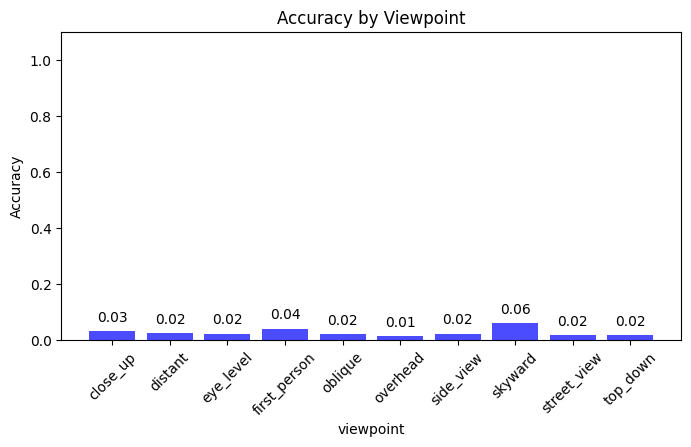

In [6]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Precision


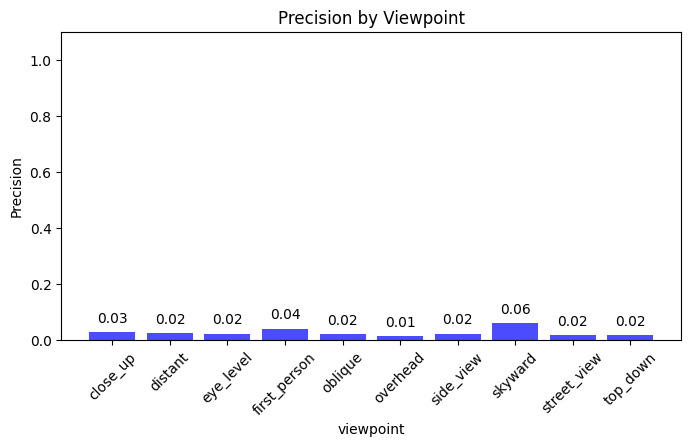

In [7]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Recall


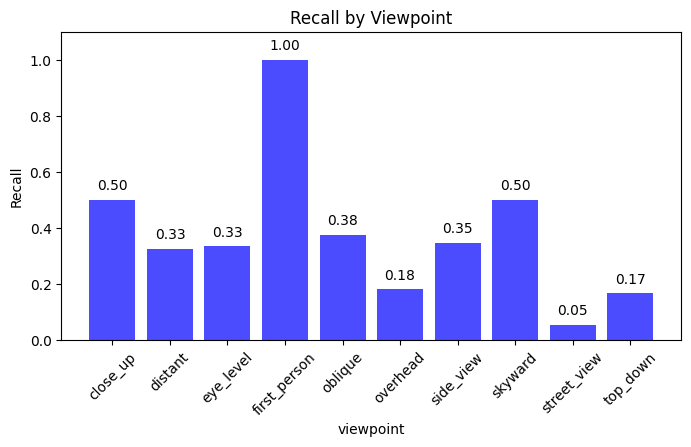

In [8]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### Hit Rate


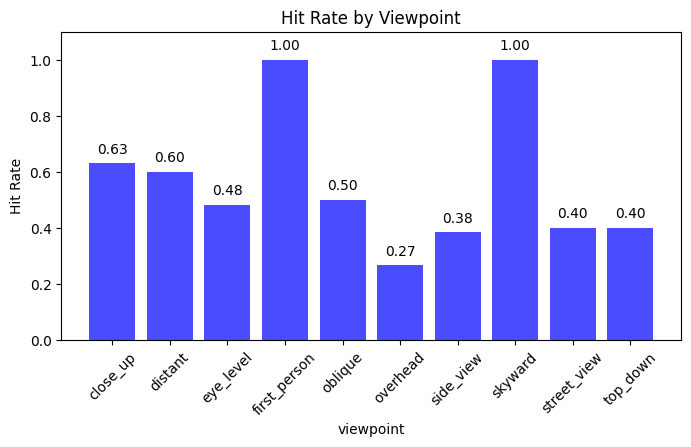

In [9]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)


### Diversity


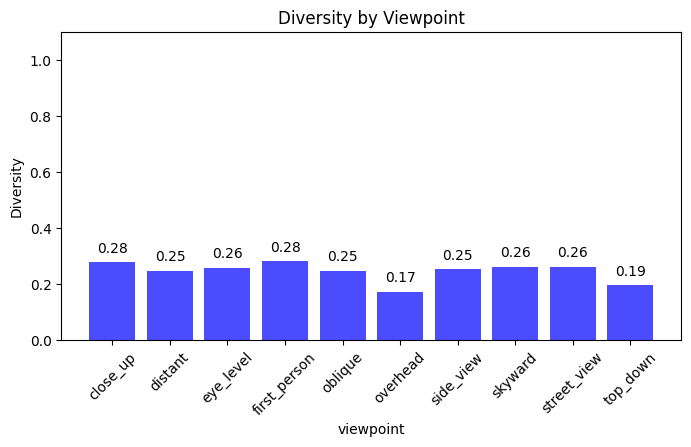

In [10]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG


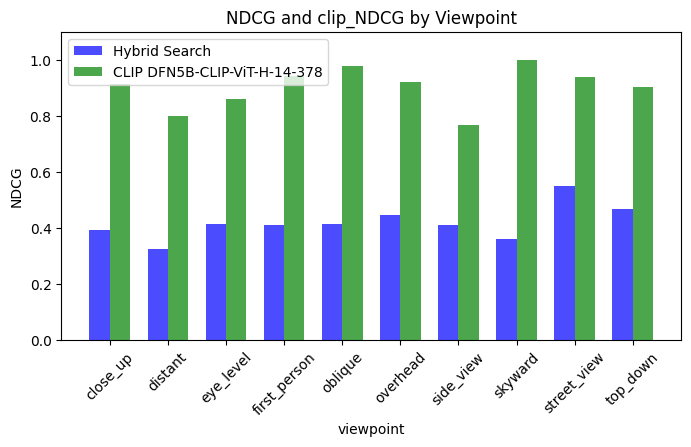

In [11]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


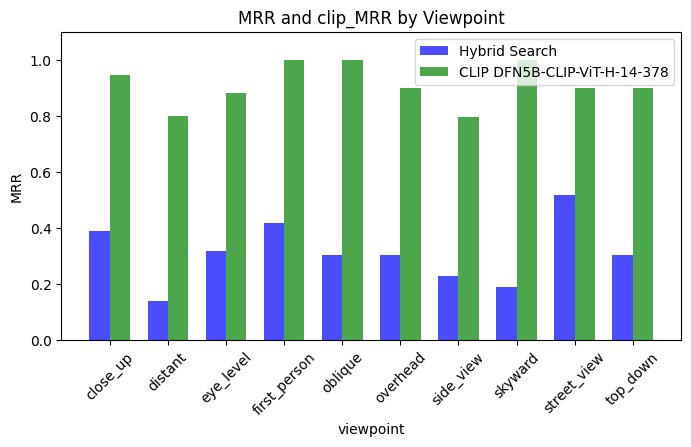

In [12]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Lighting

Now, we will evaluate queries based on their lighting.


In [13]:
# Group
section_metrics = df.groupby('lighting').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'lighting'
title = 'Lighting'

metrics


,lighting,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,backlit,75,1,74,1,74,0.013333,0.013333,0.333333,0.333333,0.216847,0.666667,0.120370,0.666667,0.286777
1,bright,100,3,97,2,98,0.030000,0.020000,0.300000,0.500000,0.358435,1.000000,0.345455,1.000000,0.293206
2,day,4375,98,4277,95,4280,0.022400,0.021714,0.343504,0.491429,0.418942,0.852232,0.311392,0.876245,0.261862
3,dusk,125,2,123,2,123,0.016000,0.016000,0.222222,0.400000,0.358544,0.666667,0.406667,0.628571,0.292543
4,indoor,1925,52,1873,50,1875,0.027013,0.025974,0.422562,0.584416,0.404388,0.914648,0.342963,0.926407,0.258116
5,night,625,8,617,8,617,0.012800,0.012800,0.188000,0.280000,0.449869,0.915313,0.339649,0.920000,0.167648
6,shadow,50,1,49,1,49,0.020000,0.020000,0.500000,0.500000,0.453397,0.886639,0.125000,1.000000,0.351401


### Accuracy


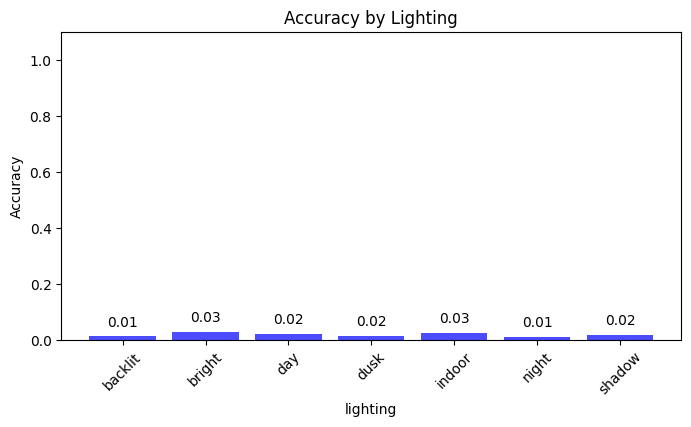

In [14]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Precision


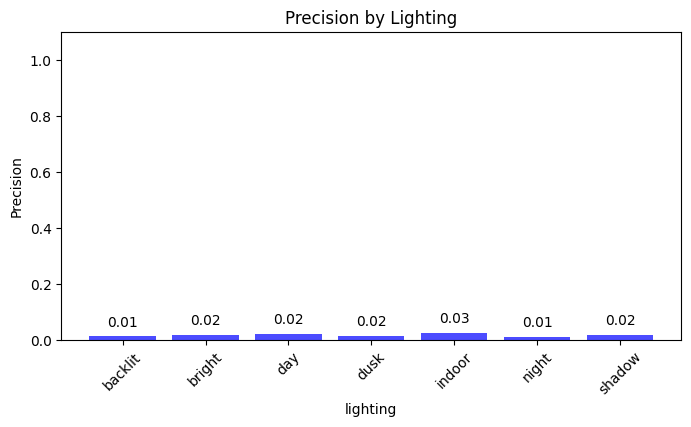

In [15]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Hit Rate


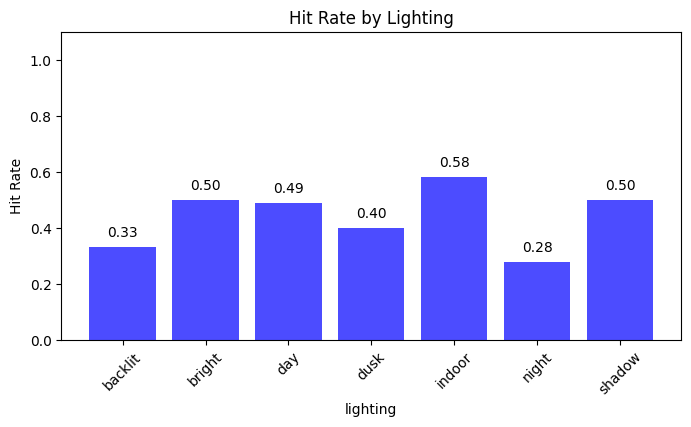

In [16]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)


### Diversity



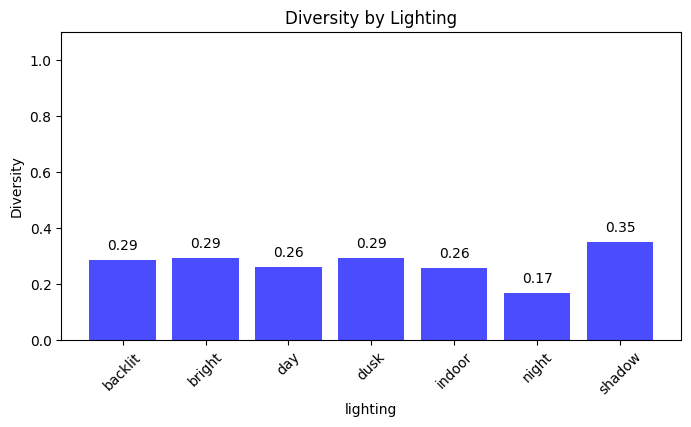

In [17]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### Recall


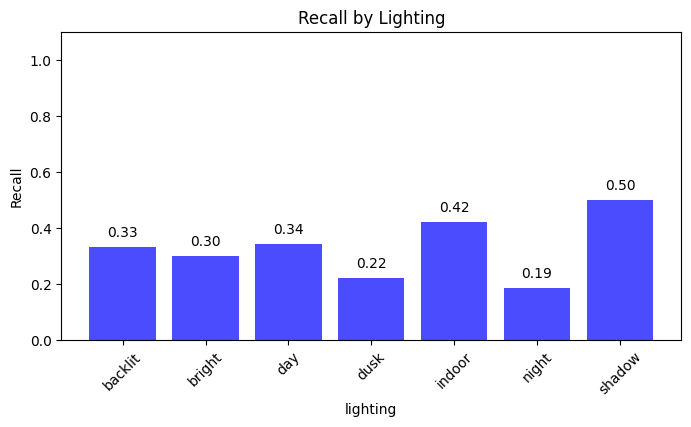

In [18]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### NDCG


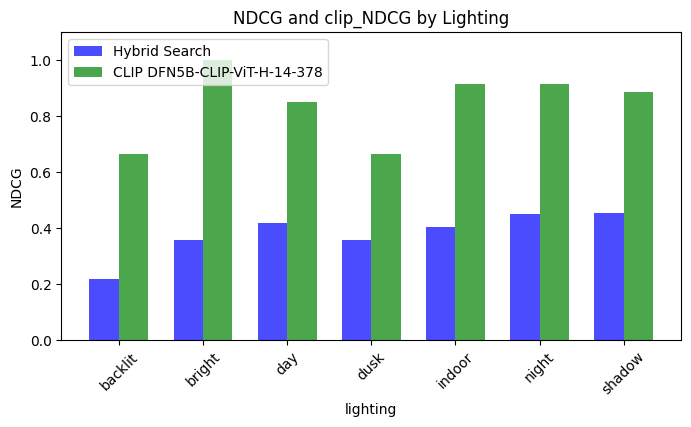

In [19]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


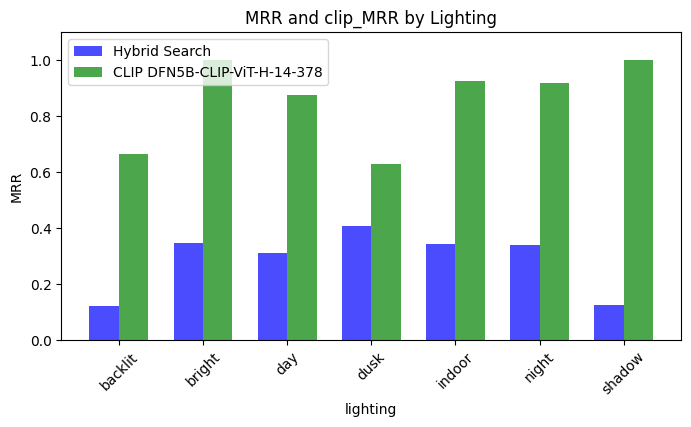

In [20]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Environment Type

Now, we will evaluate queries based on their environment type.


In [21]:
# Group
section_metrics = df.groupby('environment_type').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'environment_type'
title = 'Environment Type'

metrics


,environment_type,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,beach,100,0,100,0,100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.251100
1,indoor,1900,50,1850,48,1852,0.026316,0.025263,0.415716,0.565789,0.401101,0.926345,0.335183,0.938596,0.260706
2,industrial,100,2,98,2,98,0.020000,0.020000,0.375000,0.500000,0.313921,0.750000,0.275000,0.750000,0.212238
3,natural,300,11,289,11,289,0.036667,0.036667,0.532680,0.750000,0.441358,0.947329,0.380671,0.944444,0.178849
4,outdoor,2450,61,2389,60,2390,0.024898,0.024490,0.412597,0.551020,0.386600,0.818744,0.305540,0.851555,0.264384
5,park,50,2,48,2,48,0.040000,0.040000,0.750000,1.000000,0.475236,0.895193,0.583333,1.000000,0.342194
6,recreational,50,2,48,2,48,0.040000,0.040000,0.666667,1.000000,0.453397,0.928544,0.300000,1.000000,0.250316
7,residential,175,7,168,5,170,0.040000,0.028571,0.520408,0.714286,0.418731,0.970417,0.476566,1.000000,0.279324
8,rural,475,9,466,8,467,0.018947,0.016842,0.285486,0.421053,0.392470,0.813897,0.287182,0.826316,0.281188
9,suburban,25,0,25,0,25,0.000000,0.000000,0.000000,0.000000,0.457928,0.765630,0.500000,1.000000,0.269161


### Accuracy


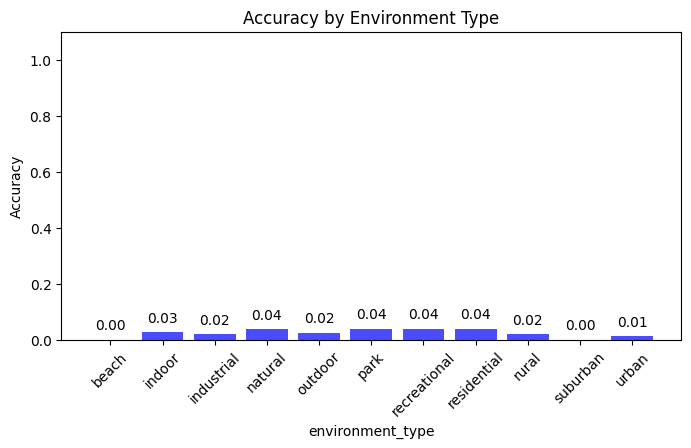

In [22]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Hit Rate


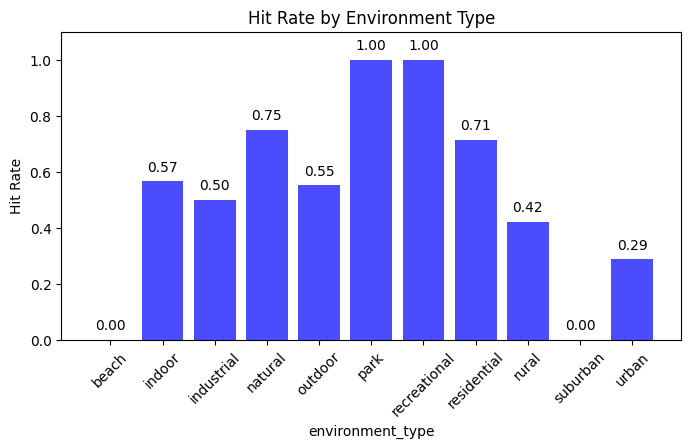

In [23]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)


### Precision


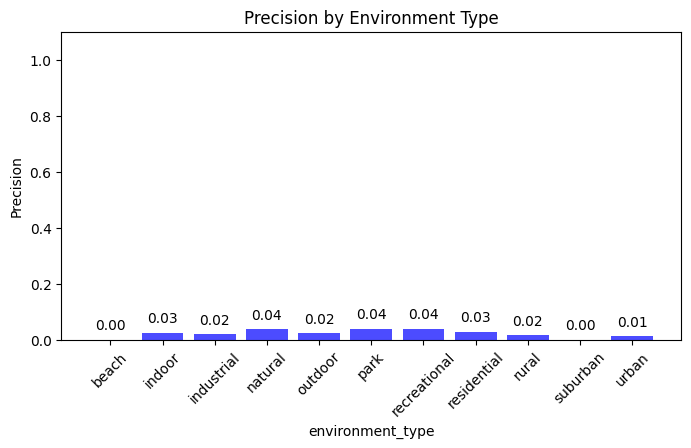

In [24]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Recall


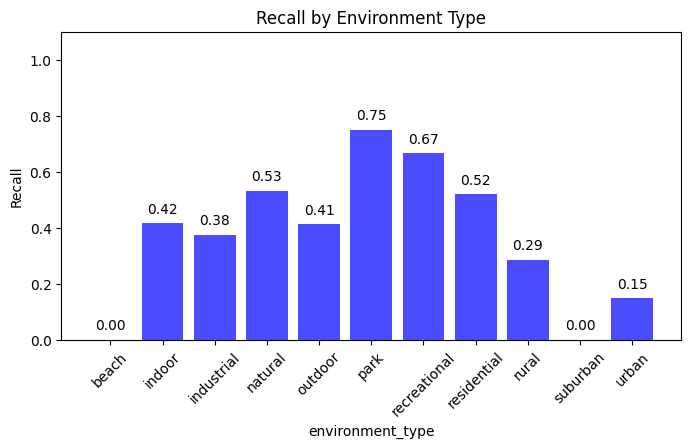

In [25]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### Diversity


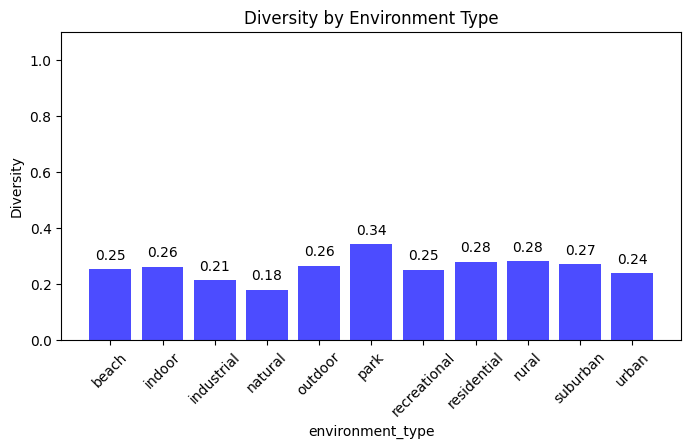

In [26]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG


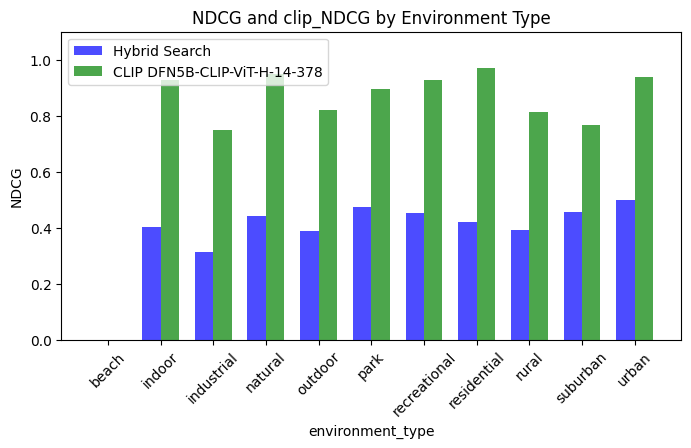

In [27]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


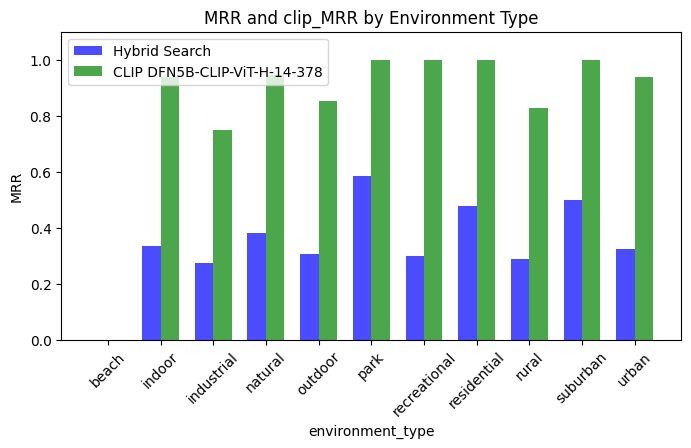

In [28]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Multiple Objects

Now, we will evaluate queries based on if they have multiple objects.


In [29]:
# Group
section_metrics = df.groupby('multiple_objects').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
section_metrics['multiple_objects'] = section_metrics['multiple_objects'].map({True: 'True', False: 'False'})

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'multiple_objects'
title = 'Multiple Objects'

metrics


,multiple_objects,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,325,8,317,8,317,0.024615,0.024615,0.403846,0.538462,0.400413,0.884689,0.209890,0.923077,0.229955
1,True,6950,157,6793,151,6799,0.022590,0.021727,0.346805,0.492806,0.414669,0.870709,0.326225,0.887838,0.255760


### Hit Rate


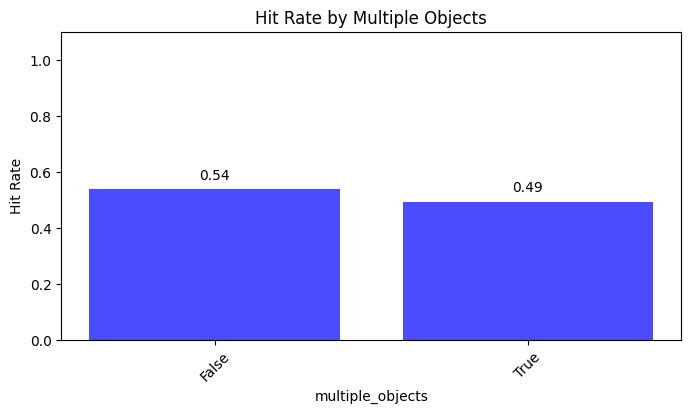

In [30]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)


### Accuracy


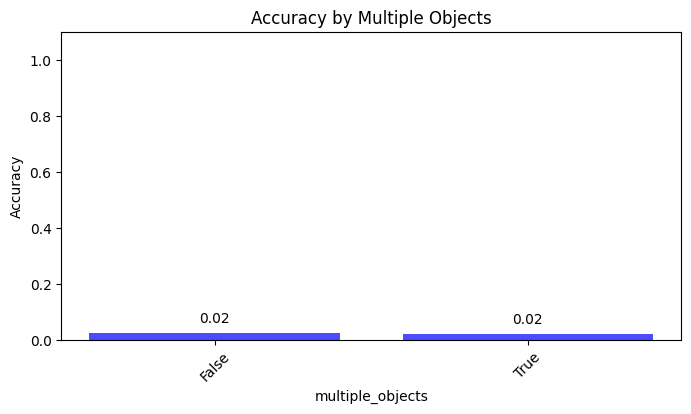

In [31]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Precision


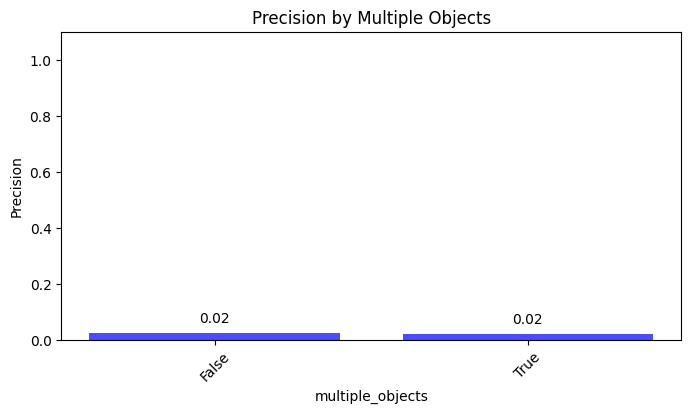

In [32]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Recall


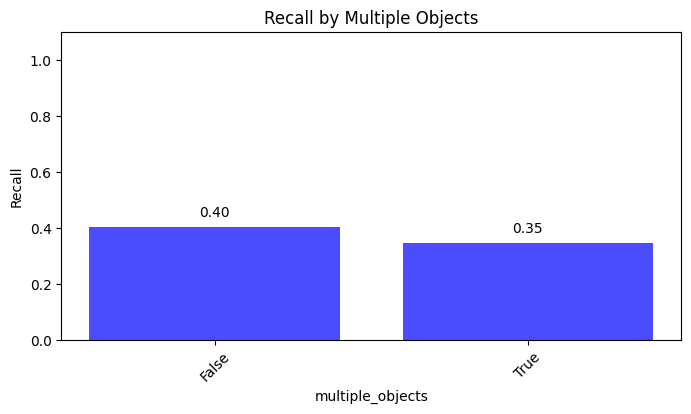

In [33]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### Diversity



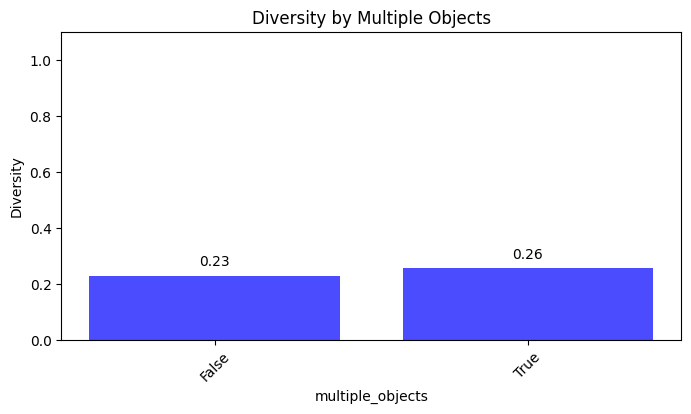

In [34]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG


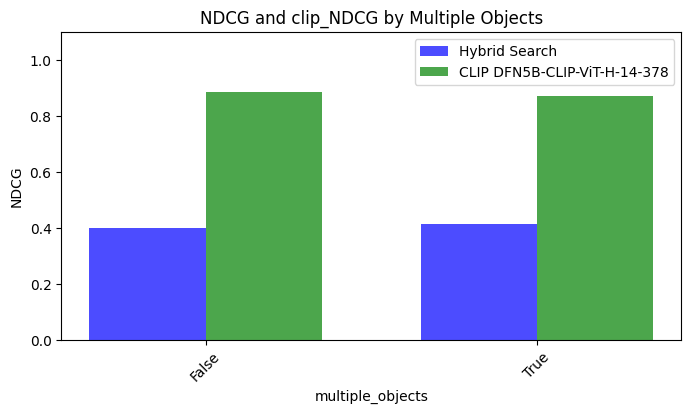

In [35]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


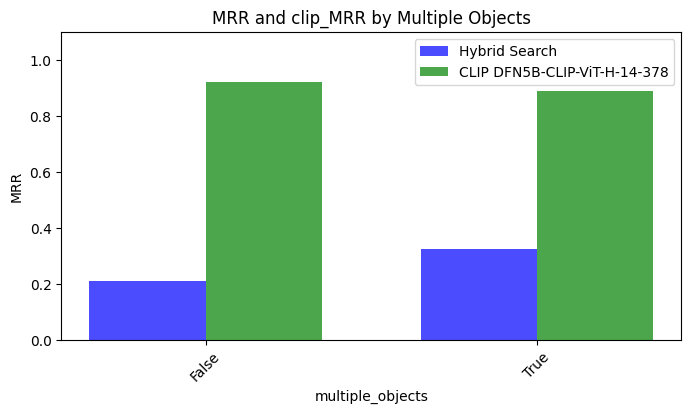

In [36]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Artificial Lighting

Now, we will evaluate queries based on if they have artificial lighting.


In [37]:
# Group
section_metrics = df.groupby('artificial_lighting').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
section_metrics['artificial_lighting'] = section_metrics['artificial_lighting'].map({True: 'True', False: 'False'})

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'artificial_lighting'
title = 'Artificial Lighting'

metrics


,artificial_lighting,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,4800,106,4694,104,4696,0.022083,0.021667,0.352152,0.494792,0.412514,0.845764,0.311937,0.867113,0.258748
1,True,2475,59,2416,55,2420,0.023838,0.022222,0.343923,0.494949,0.416976,0.920922,0.338659,0.932660,0.246578


### Accuracy


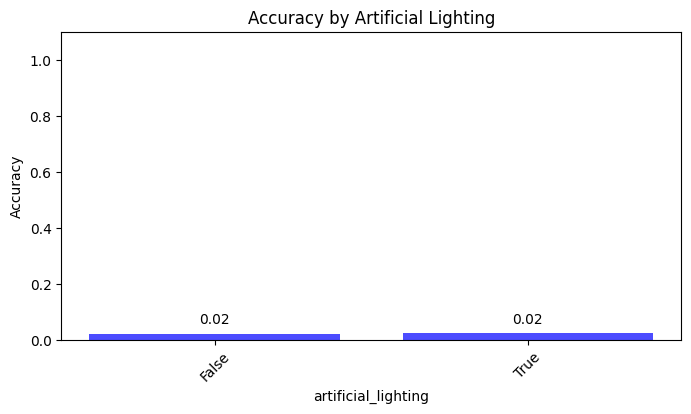

In [38]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Precision


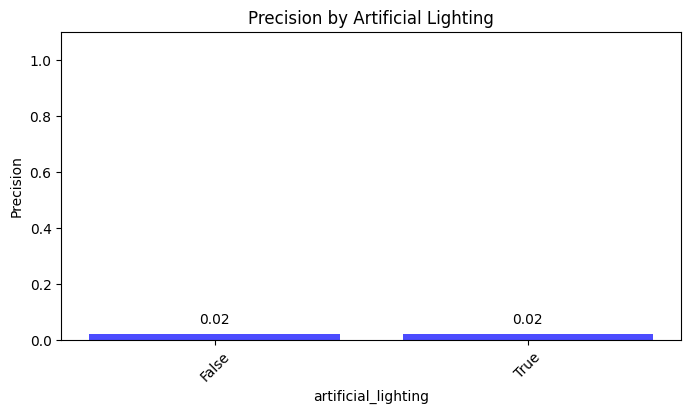

In [39]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Recall


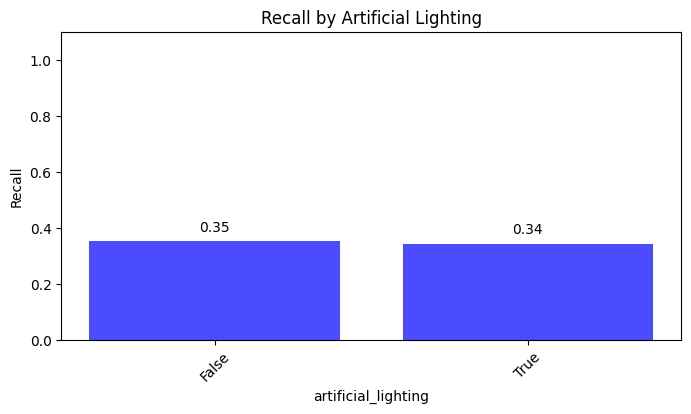

In [40]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### Hit Rate


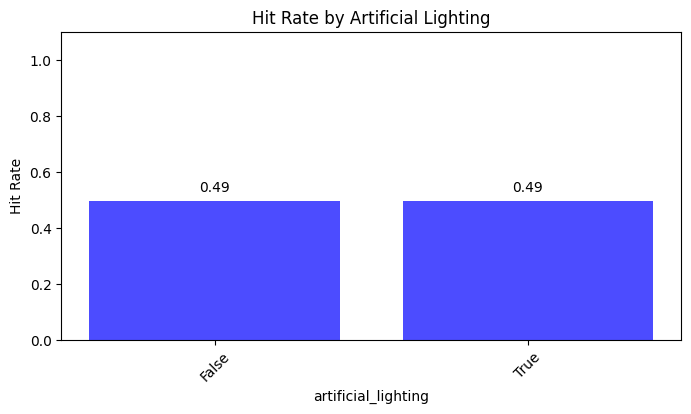

In [41]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)


### Diversity



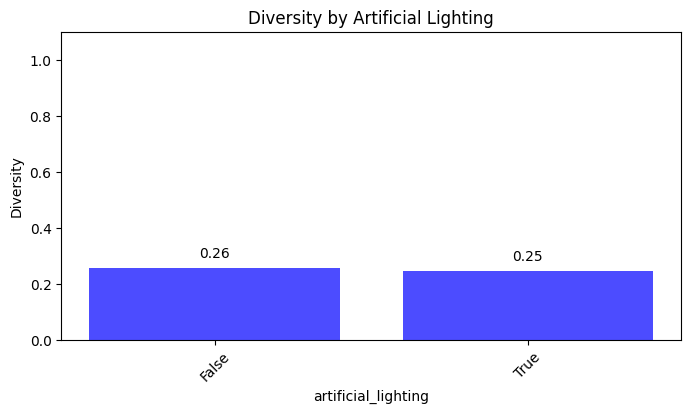

In [42]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG


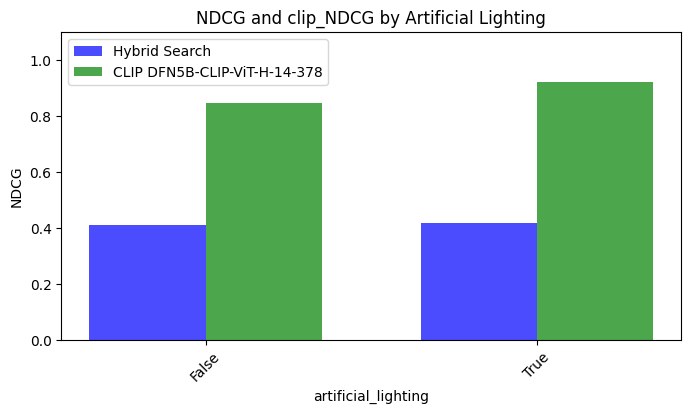

In [43]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


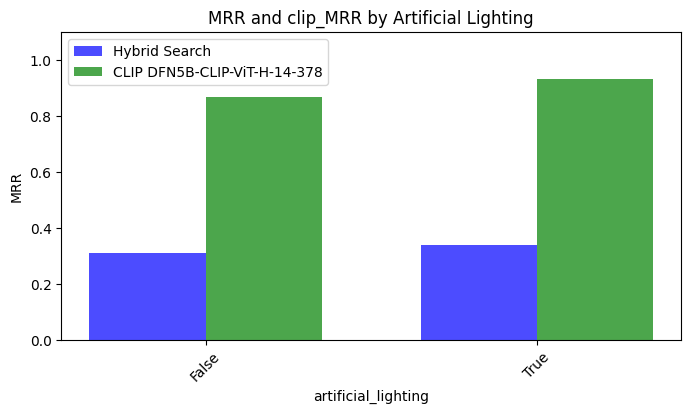

In [44]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Occlusion Present

Now, we will evaluate queries based on if they have occlusion present.


In [45]:
# Group
section_metrics = df.groupby('occlusion_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
section_metrics['occlusion_present'] = section_metrics['occlusion_present'].map({True: 'True', False: 'False'})

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'occlusion_present'
title = 'Occlusion Present'

metrics


,occlusion_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,4950,102,4848,99,4851,0.020606,0.020000,0.325704,0.454545,0.415413,0.879522,0.29889,0.898990,0.245557
1,True,2325,63,2262,60,2265,0.027097,0.025806,0.399701,0.580645,0.411092,0.853900,0.36816,0.869022,0.273875


### Accuracy


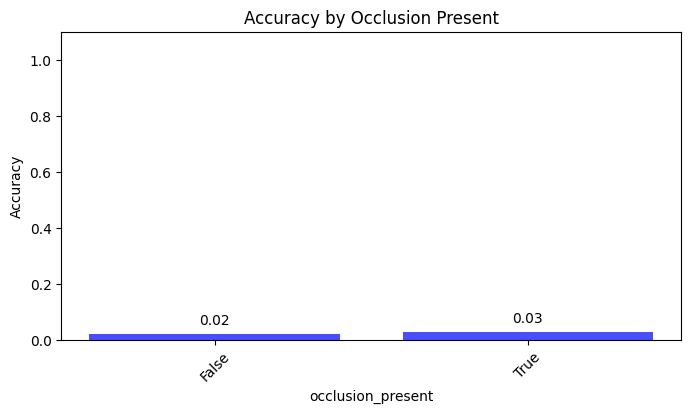

In [46]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Precision


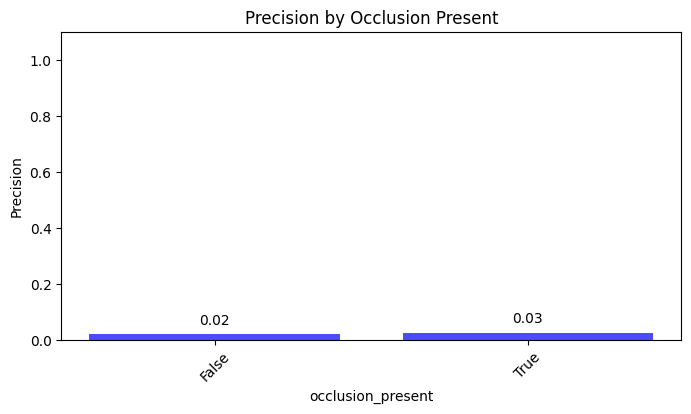

In [47]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Recall


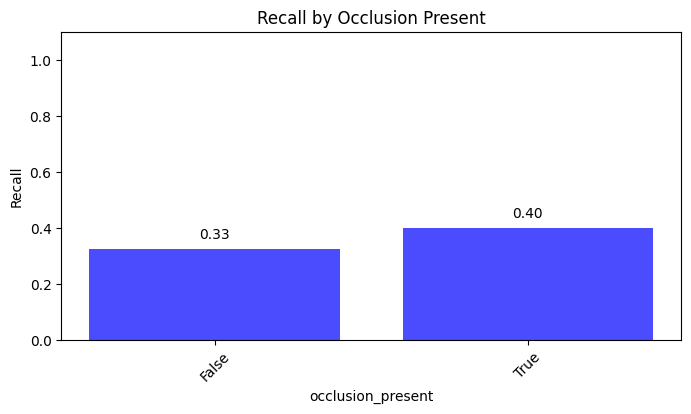

In [48]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### Hit Rate


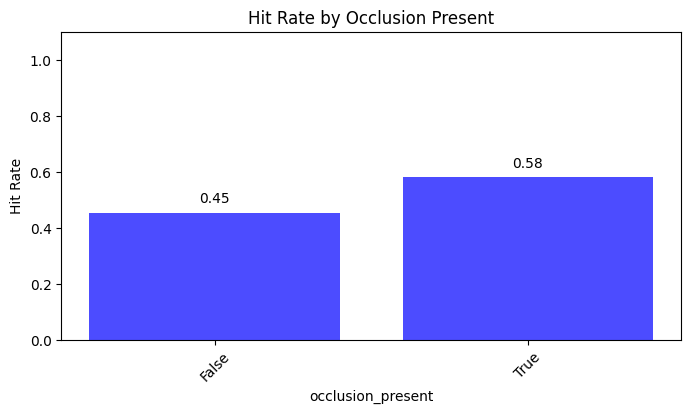

In [49]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)


### Diversity



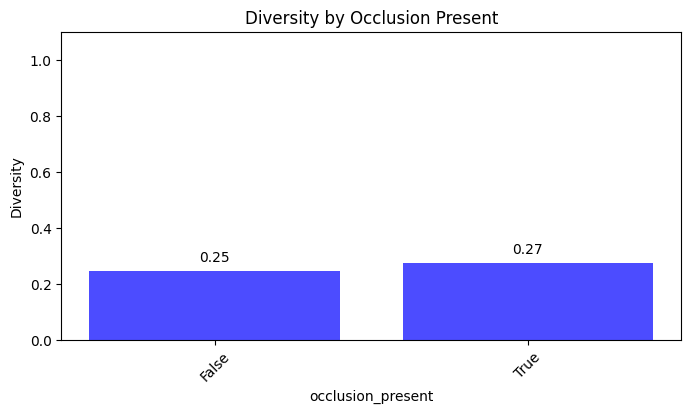

In [50]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG


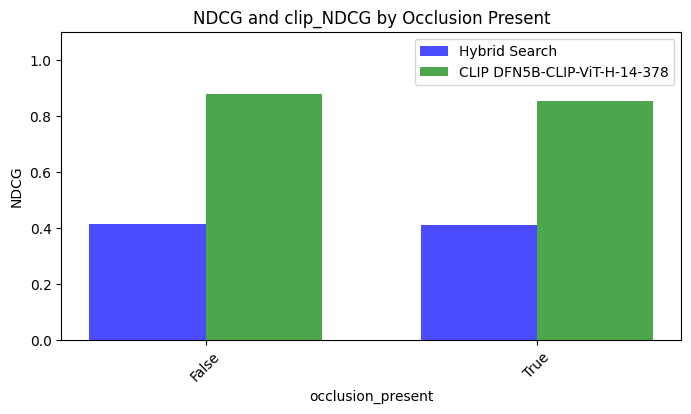

In [51]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


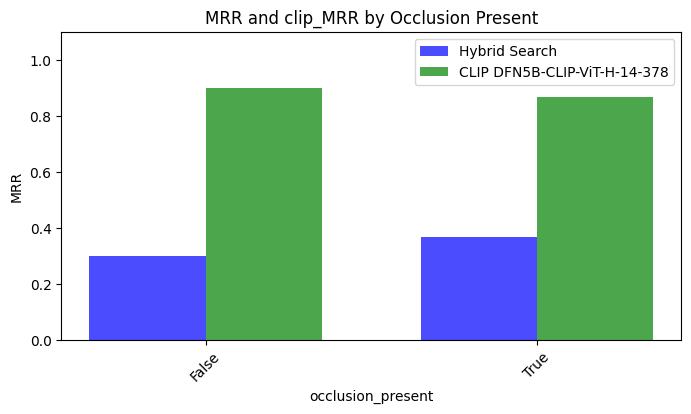

In [52]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Text Visible

Now, we will evaluate queries based on if they have text visible.


In [53]:
# Group
section_metrics = df.groupby('text_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
section_metrics['text_visible'] = section_metrics['text_visible'].map({True: 'True', False: 'False'})

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'text_visible'
title = 'Text Visible'

metrics


,text_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,4350,108,4242,106,4244,0.024828,0.024368,0.413910,0.557471,0.408291,0.882865,0.322192,0.907909,0.246146
1,True,2925,57,2868,53,2872,0.019487,0.018120,0.253345,0.401709,0.422569,0.854184,0.319297,0.861905,0.267191


### Accuracy


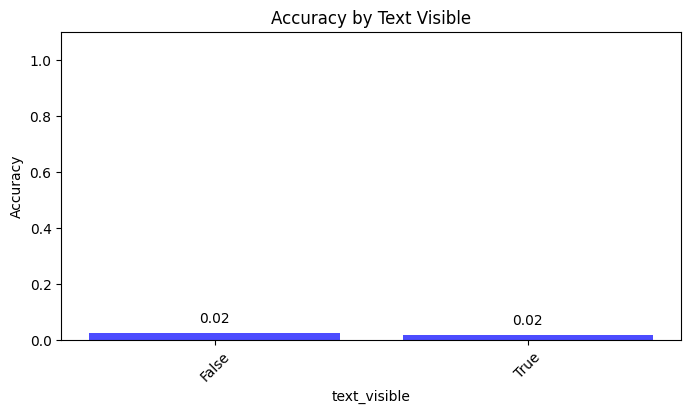

In [54]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Precision


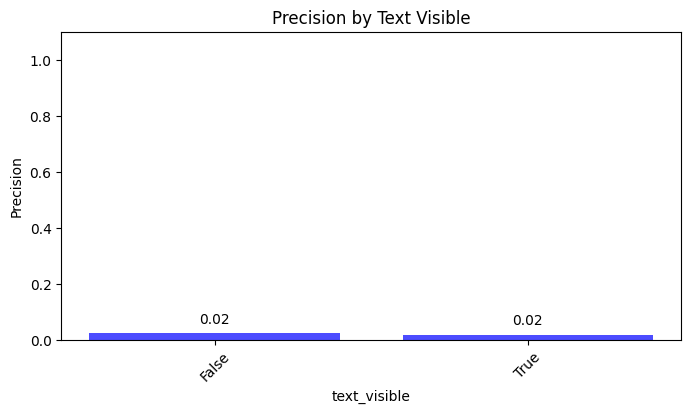

In [55]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Hit Rate


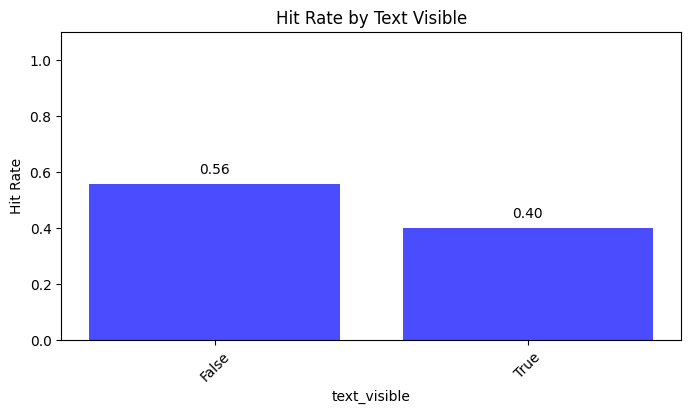

In [56]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)


### Diversity




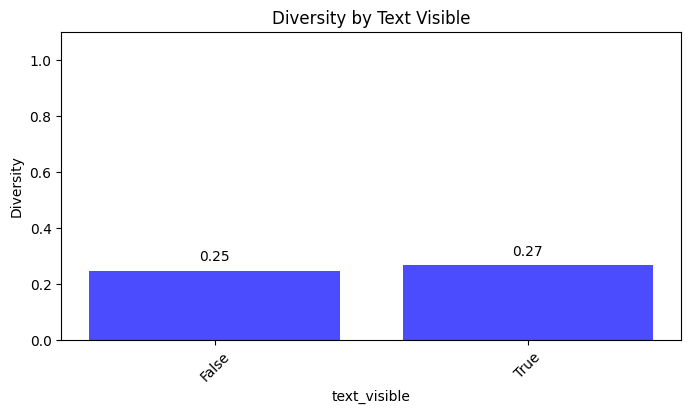

In [57]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### Recall


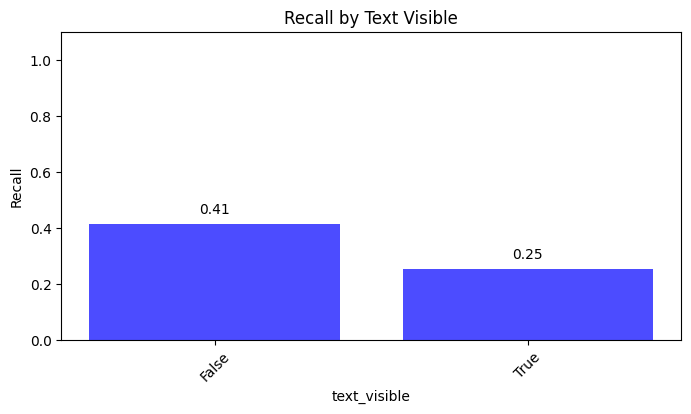

In [58]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### NDCG


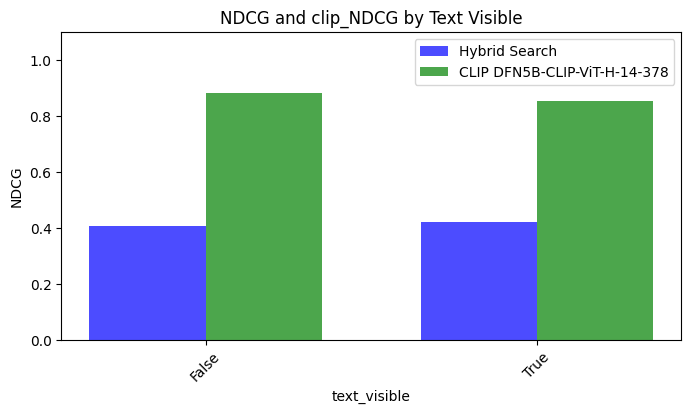

In [59]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


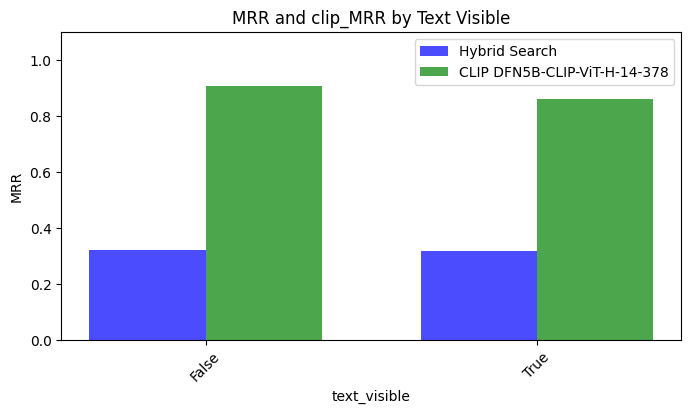

In [60]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Person Present

Now, we will evaluate queries based on if they have a person present.


In [61]:
# Group
section_metrics = df.groupby('person_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
section_metrics['person_present'] = section_metrics['person_present'].map({True: 'True', False: 'False'})

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'person_present'
title = 'Person Present'

metrics


,person_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,4175,95,4080,93,4082,0.022754,0.022275,0.320051,0.485030,0.416800,0.886860,0.298968,0.909096,0.229038
1,True,3100,70,3030,66,3034,0.022581,0.021290,0.388816,0.508065,0.410303,0.850422,0.350738,0.862903,0.289043


### Accuracy


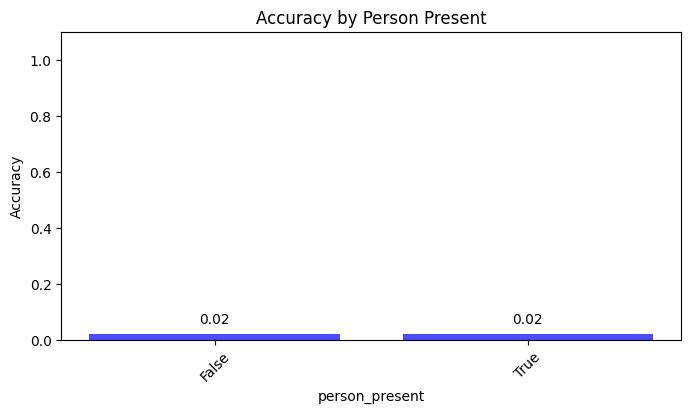

In [62]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Hit Rate


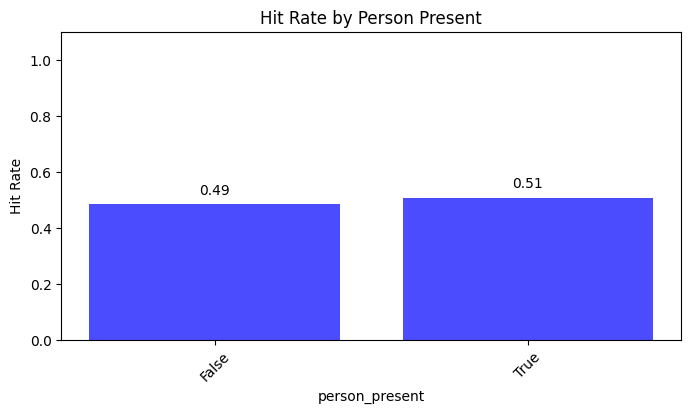

In [63]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)


### Precision


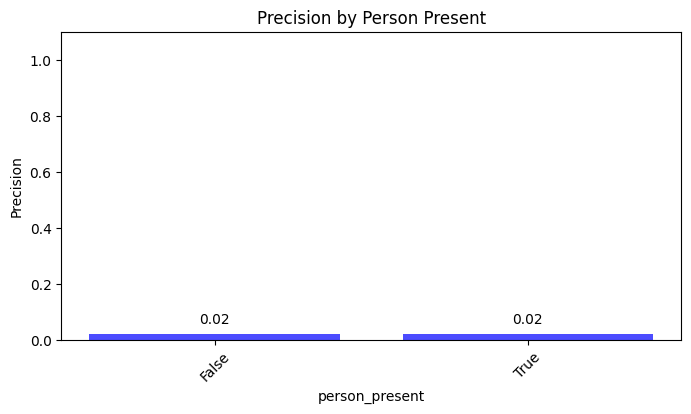

In [64]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Recall


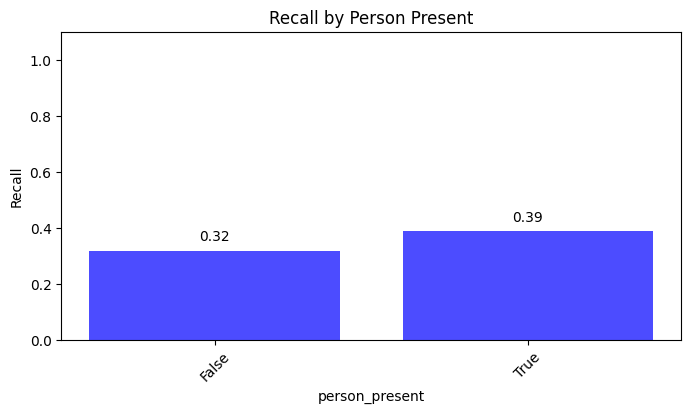

In [65]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### Diversity




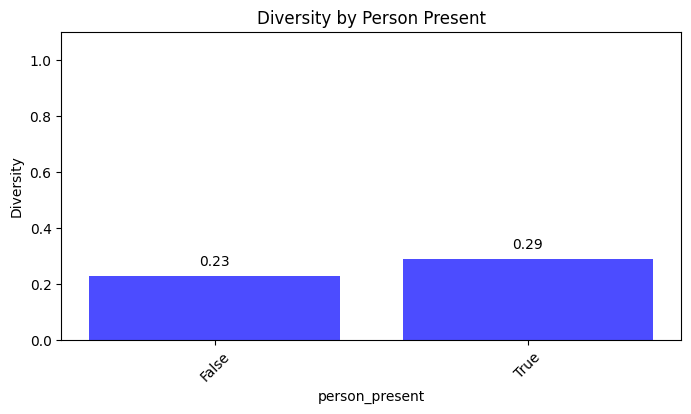

In [66]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG


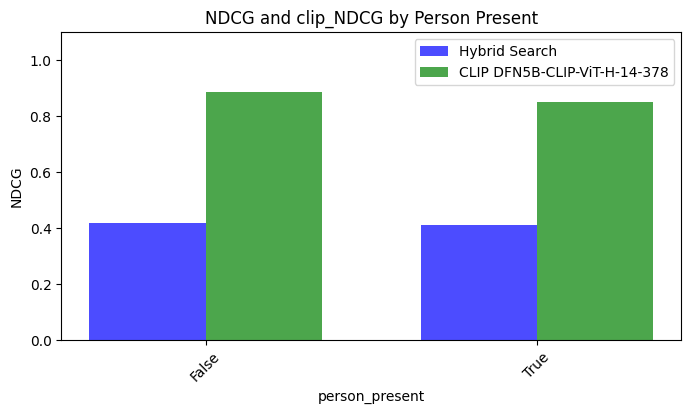

In [67]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


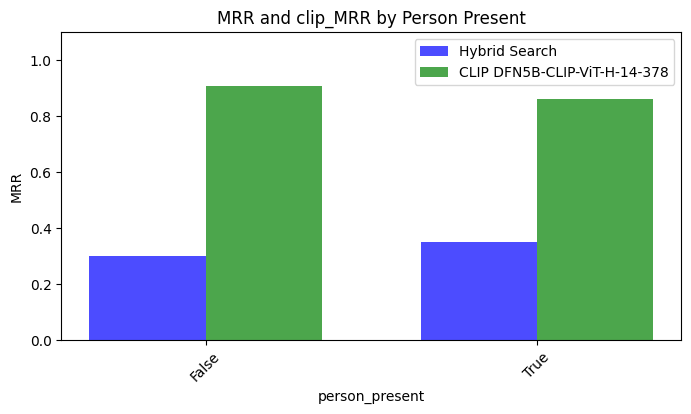

In [68]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Animal Present

Now, we will evaluate queries based on if they have an animal present.


In [69]:
# Group
section_metrics = df.groupby('animal_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
section_metrics['animal_present'] = section_metrics['animal_present'].map({True: 'True', False: 'False'})

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'animal_present'
title = 'Animal Present'

metrics


,animal_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,6200,126,6074,122,6078,0.020323,0.019677,0.292655,0.439516,0.410823,0.861178,0.312723,0.874942,0.252384
1,True,1075,39,1036,37,1038,0.036279,0.034419,0.676357,0.813953,0.432539,0.929903,0.368926,0.972868,0.267430


### Accuracy


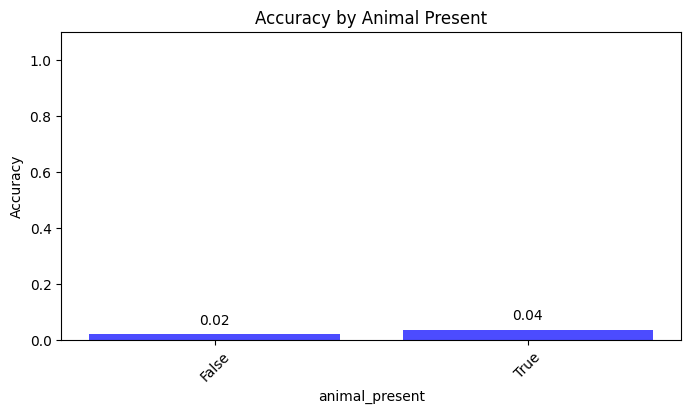

In [70]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Precision


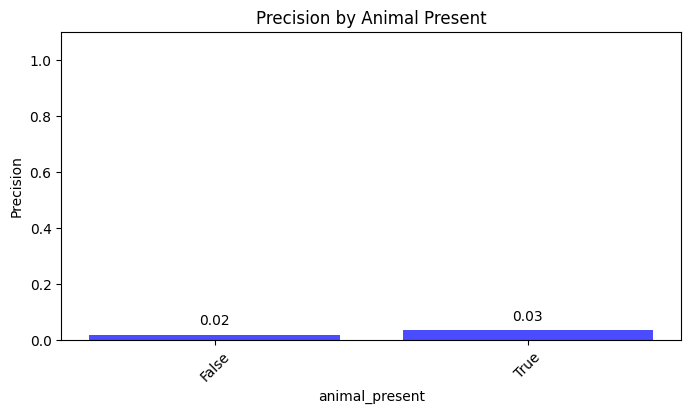

In [71]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Recall


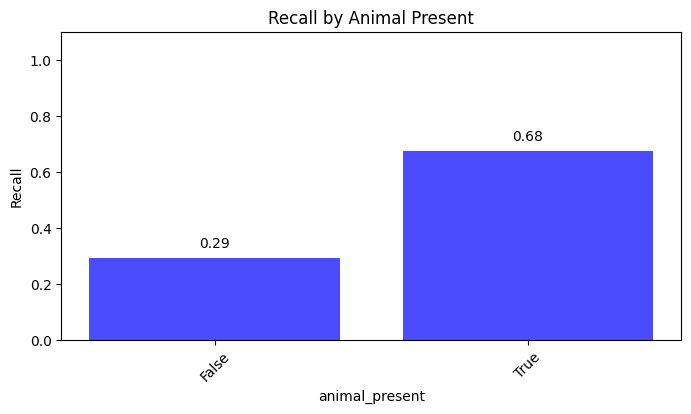

In [72]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### Hit Rate


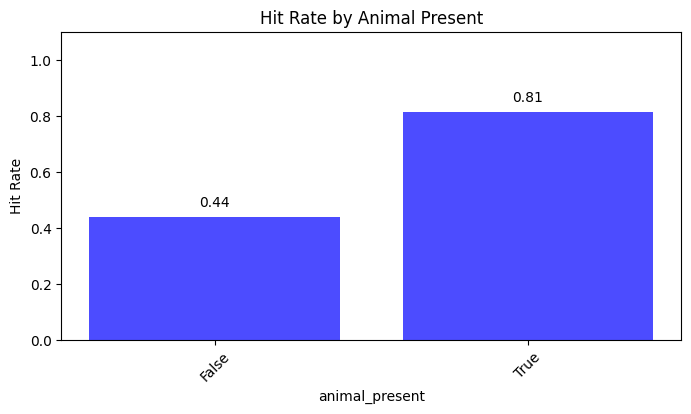

In [73]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)


### Diversity





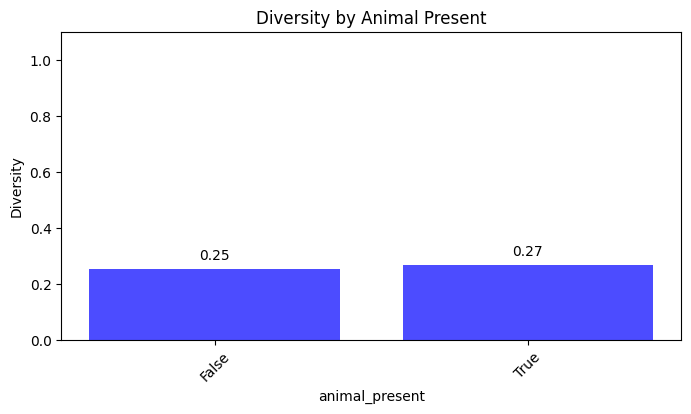

In [74]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG


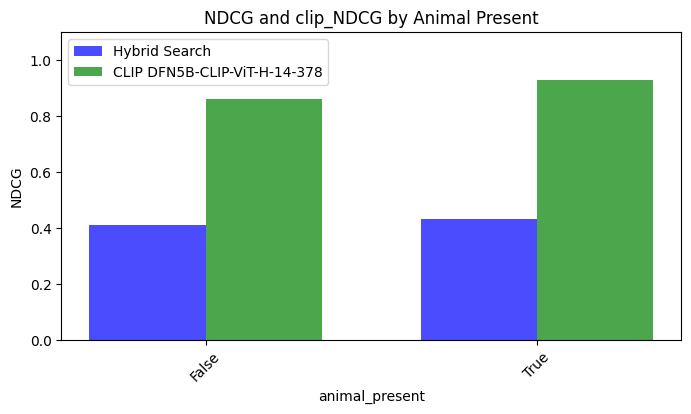

In [75]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


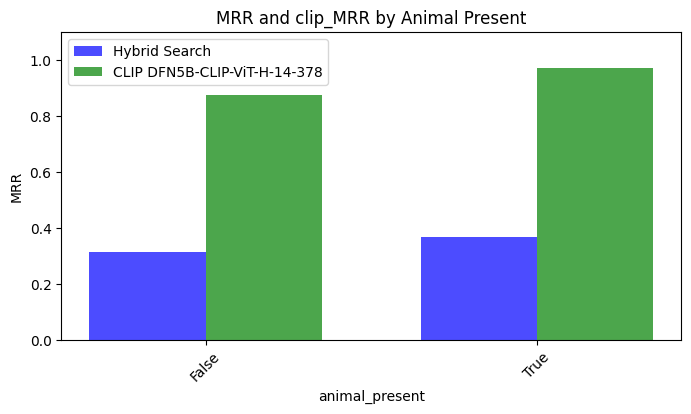

In [76]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Food Present

Now, we will evaluate queries based on if they have food present.


In [77]:
# Group
section_metrics = df.groupby('food_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
section_metrics['food_present'] = section_metrics['food_present'].map({True: 'True', False: 'False'})

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'food_present'
title = 'Food Present'

metrics


,food_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,6500,150,6350,145,6355,0.023077,0.022308,0.356776,0.503846,0.416070,0.870376,0.321599,0.887766,0.25016
1,True,775,15,760,14,761,0.019355,0.018065,0.287097,0.419355,0.396941,0.879366,0.316237,0.903226,0.29191


### Accuracy


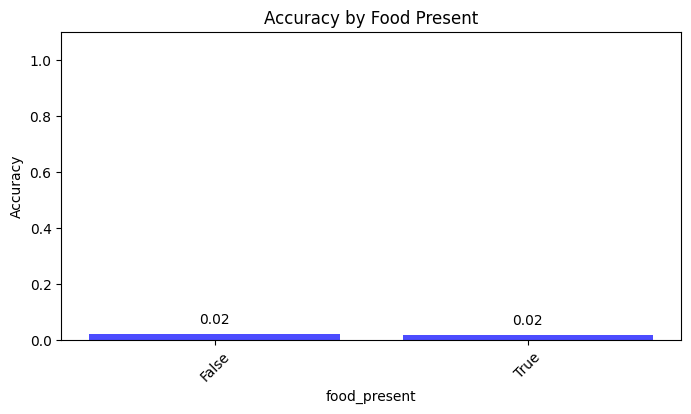

In [78]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Precision


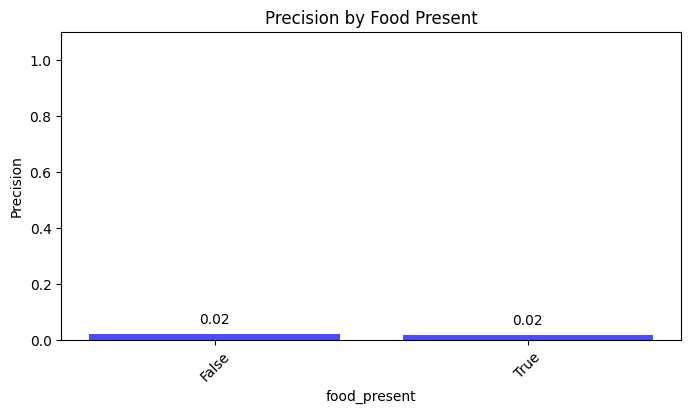

In [79]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Recall


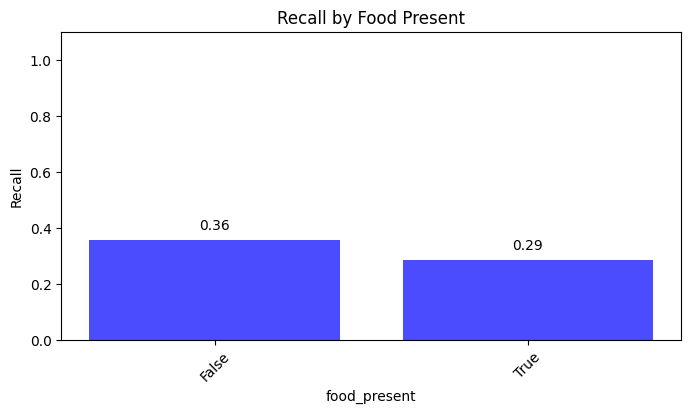

In [80]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### Hit Rate


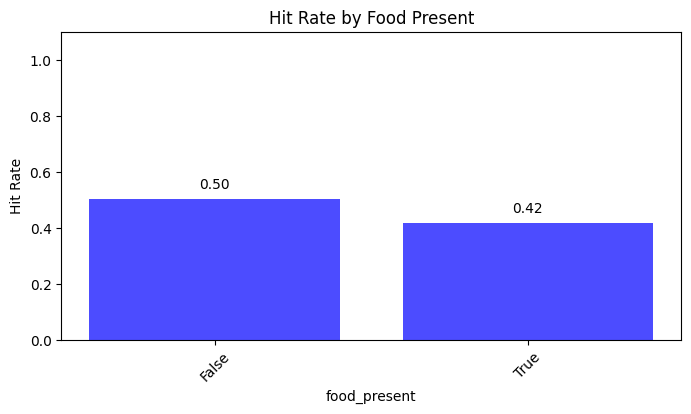

In [81]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)


### Diversity






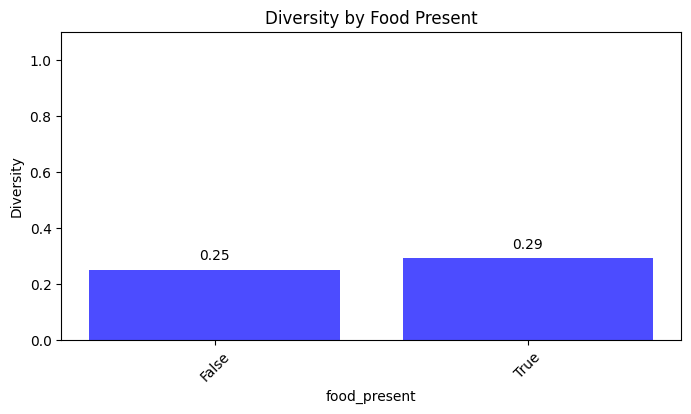

In [82]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG


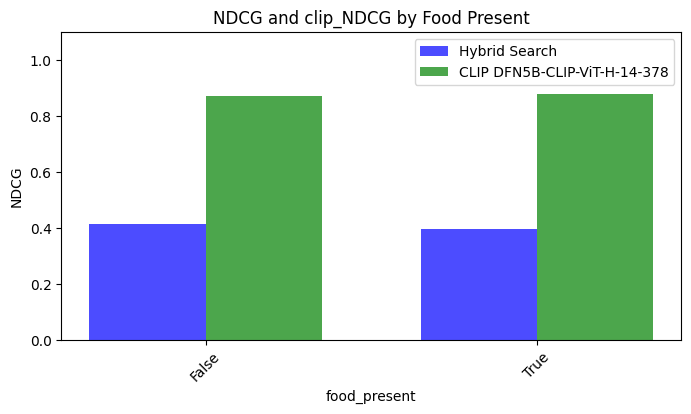

In [83]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


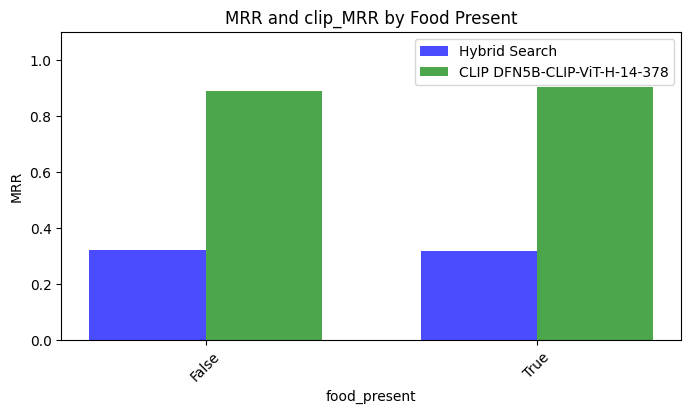

In [84]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Urban Scene

Now, we will evaluate queries based on if they have an urban scene.


In [85]:
# Group
section_metrics = df.groupby('urban_scene').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
section_metrics['urban_scene'] = section_metrics['urban_scene'].map({True: 'True', False: 'False'})

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'urban_scene'
title = 'Urban Scene'

metrics


,urban_scene,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,4925,128,4797,122,4803,0.025990,0.024772,0.408570,0.563452,0.382503,0.848251,0.306649,0.868915,0.254573
1,True,2350,37,2313,37,2313,0.015745,0.015745,0.225249,0.351064,0.480108,0.919708,0.351163,0.932371,0.254680


### Accuracy


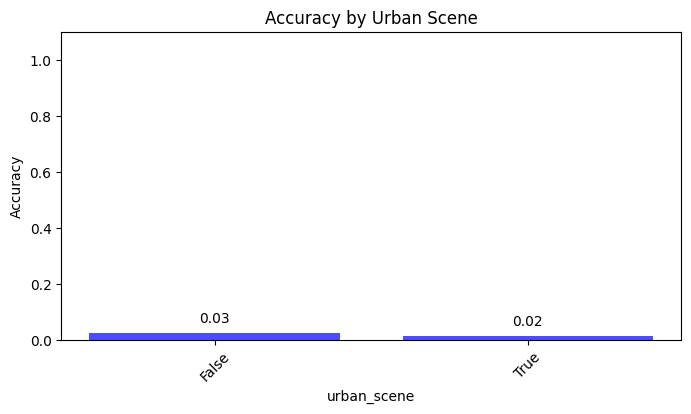

In [86]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Precision


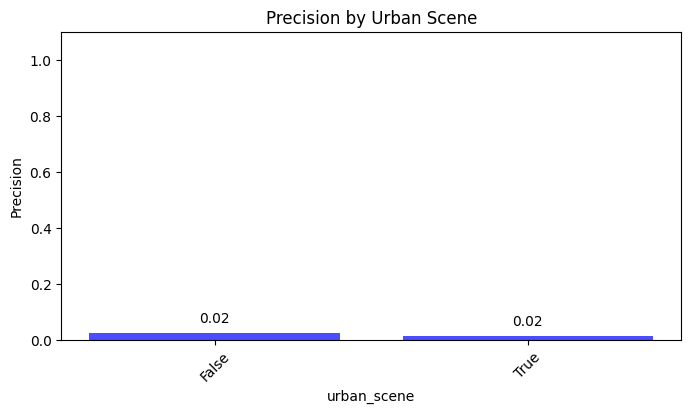

In [87]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Recall


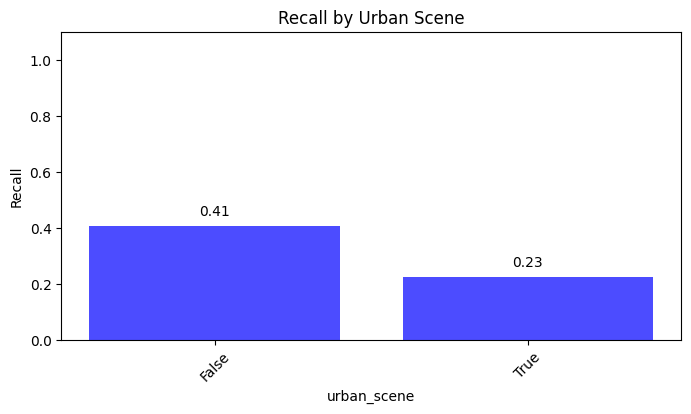

In [88]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### Hit Rate


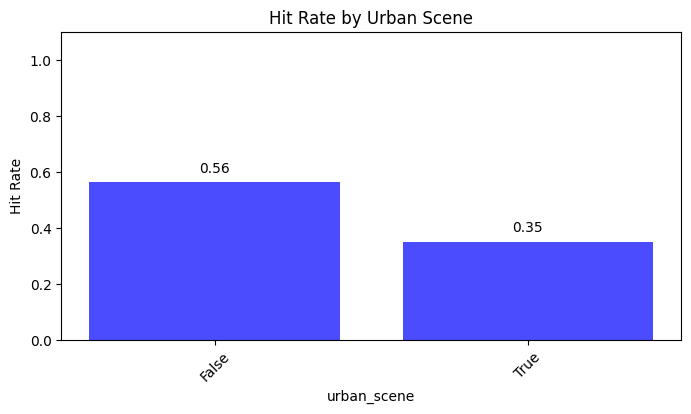

In [89]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)


### Diversity







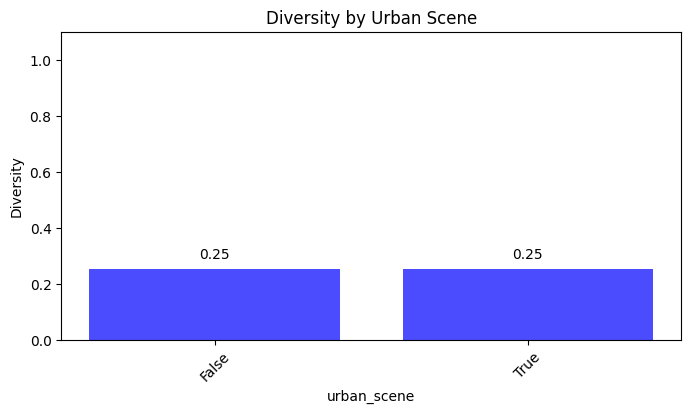

In [90]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG


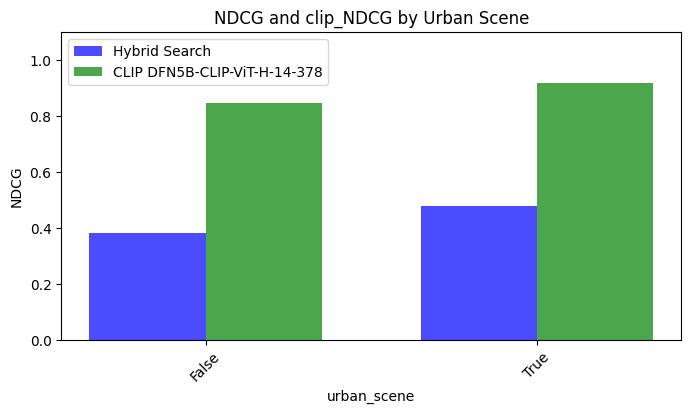

In [91]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


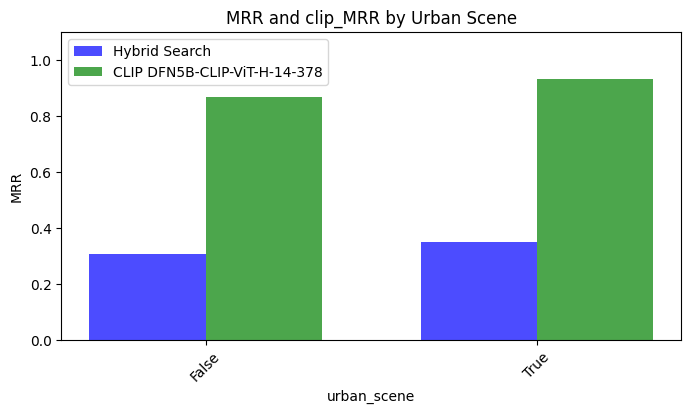

In [92]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Rural Scene

Now, we will evaluate queries based on if they have a rural scene.


In [93]:
# Group
section_metrics = df.groupby('rural_scene').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
section_metrics['rural_scene'] = section_metrics['rural_scene'].map({True: 'True', False: 'False'})

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'rural_scene'
title = 'Rural Scene'

metrics


,rural_scene,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,6000,136,5864,131,5869,0.022667,0.021833,0.35022,0.487500,0.420610,0.885255,0.331584,0.902679,0.253949
1,True,1275,29,1246,28,1247,0.022745,0.021961,0.34527,0.529412,0.383075,0.805820,0.271355,0.826984,0.257705


### Accuracy


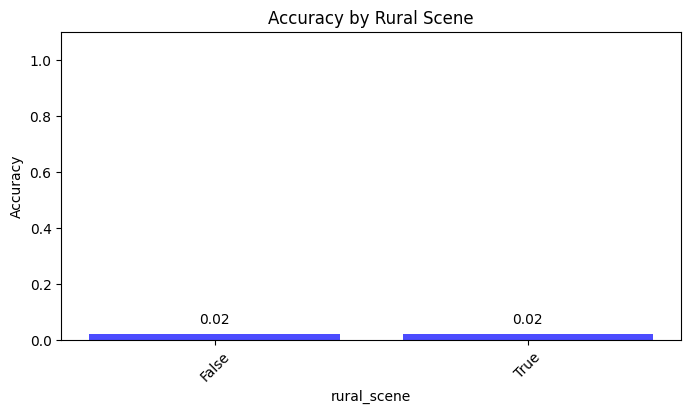

In [94]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Precision


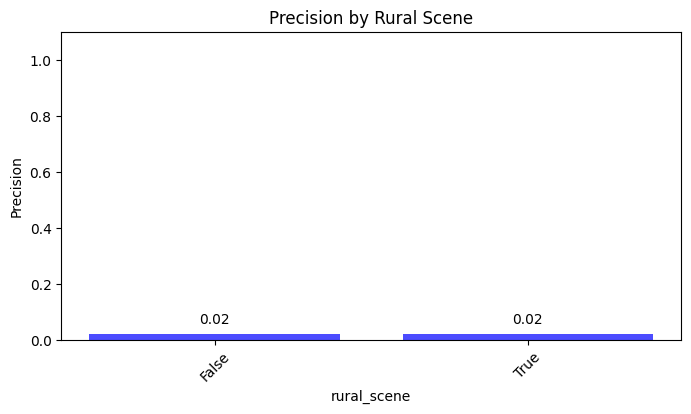

In [95]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Hit Rate


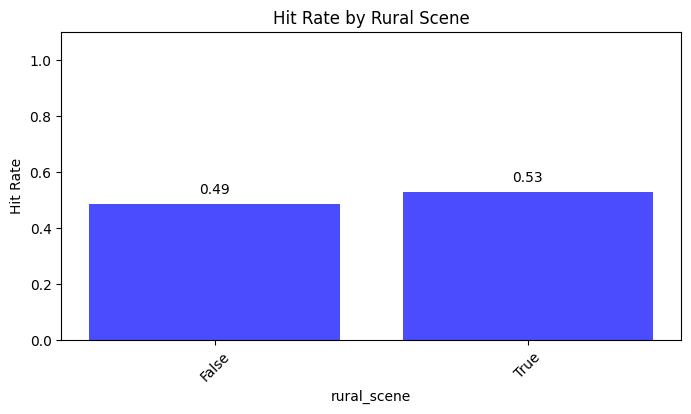

In [96]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)


### Diversity







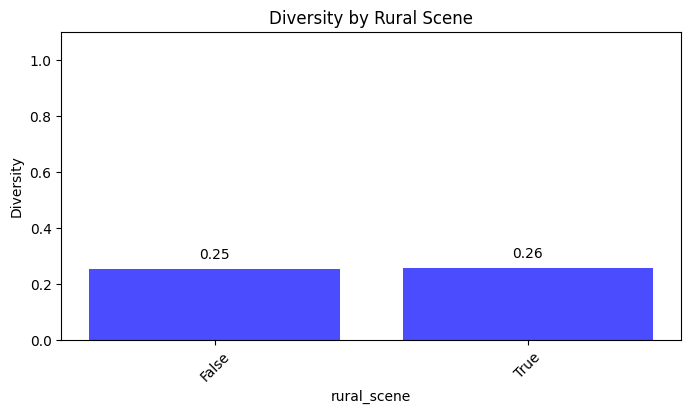

In [97]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### Recall


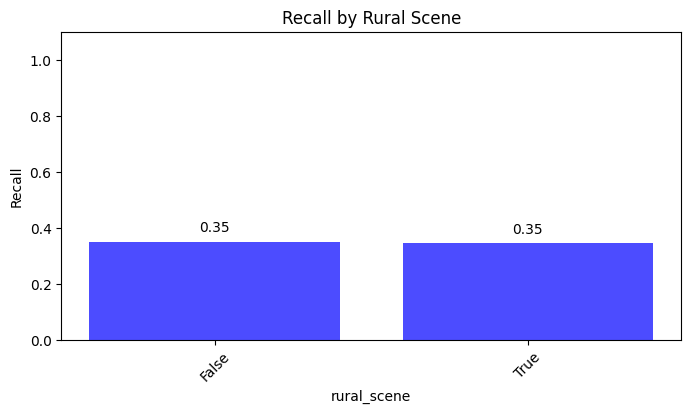

In [98]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### NDCG


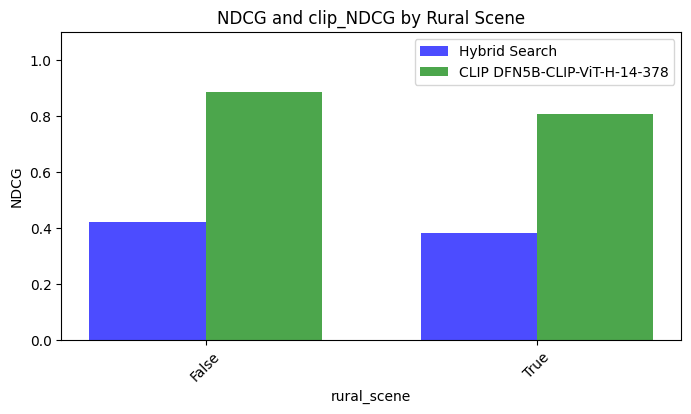

In [99]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


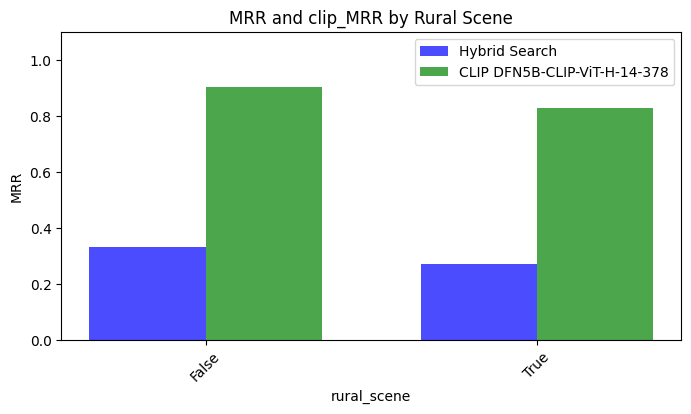

In [100]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Outdoor Scene

Now, we will evaluate queries based on if they have an outdoor scene.


In [101]:
# Group
section_metrics = df.groupby('outdoor_scene').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
section_metrics['outdoor_scene'] = section_metrics['outdoor_scene'].map({True: 'True', False: 'False'})

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'outdoor_scene'
title = 'Outdoor Scene'

metrics


,outdoor_scene,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2125,56,2069,53,2072,0.026353,0.024941,0.408674,0.564706,0.397808,0.922910,0.337763,0.933333,0.258769
1,True,5150,109,5041,106,5044,0.021165,0.020583,0.324876,0.466019,0.420726,0.850052,0.314123,0.871290,0.252890


### Accuracy


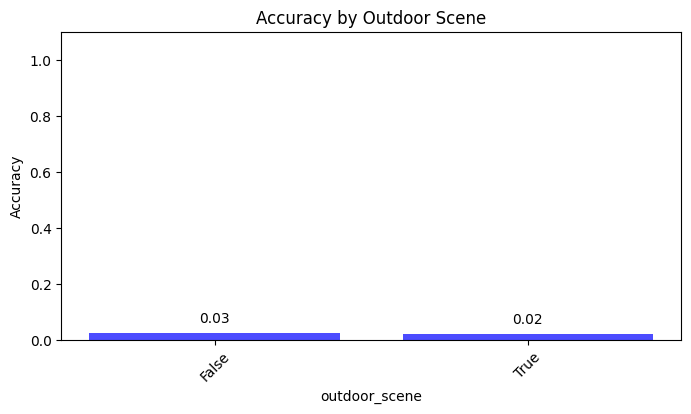

In [102]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Precision


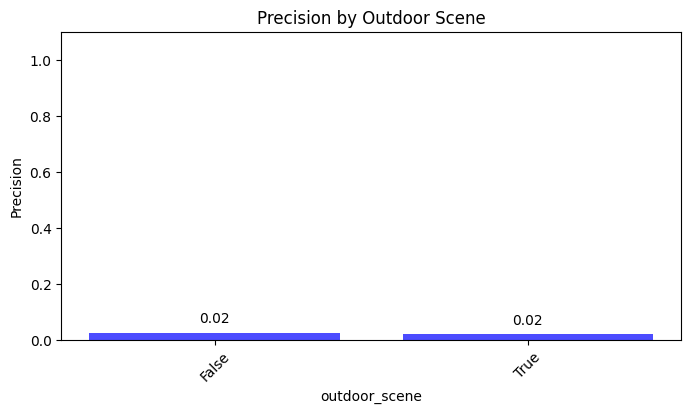

In [103]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Recall


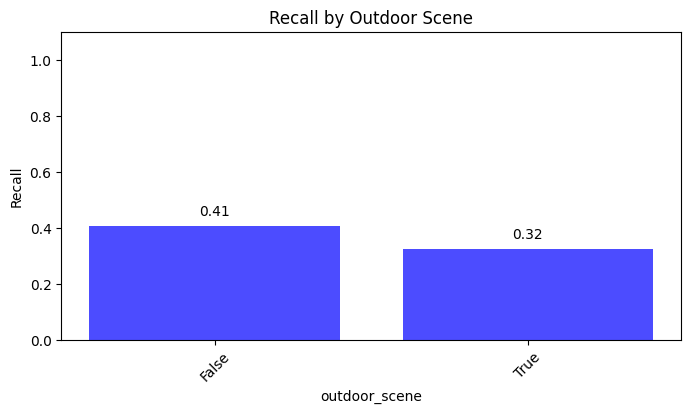

In [104]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### Hit Rate

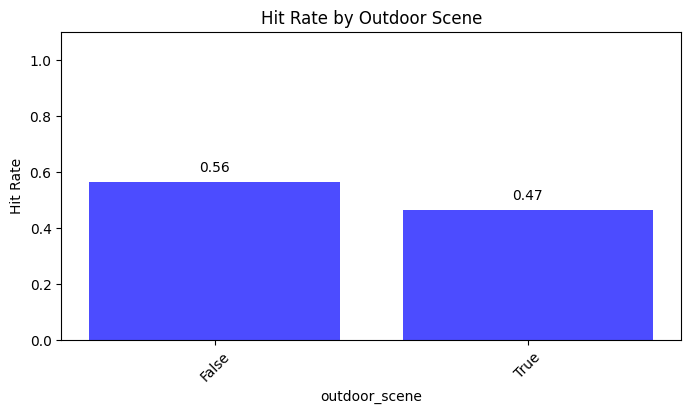

In [105]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

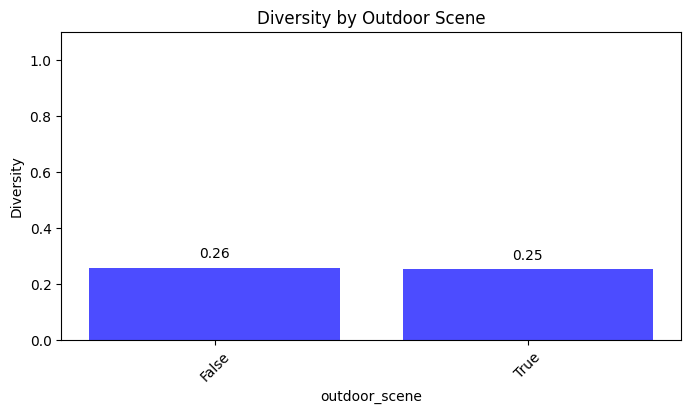

In [106]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG


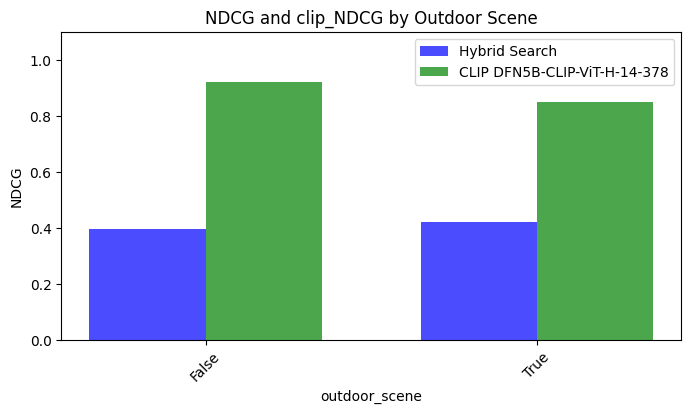

In [107]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


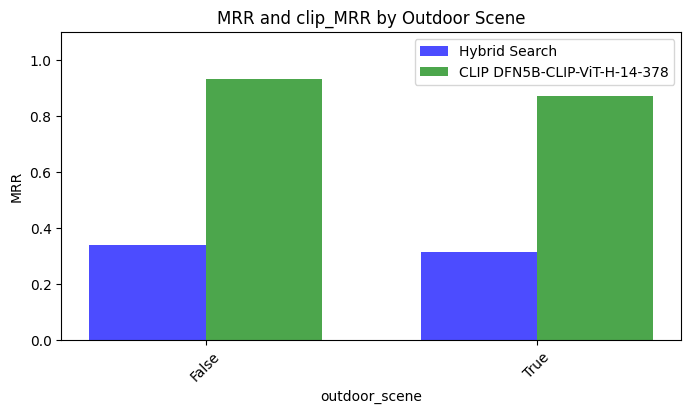

In [108]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Vehicle Present

Now, we will evaluate queries based on if they have a vehicle present.


In [109]:
# Group
section_metrics = df.groupby('vehicle_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
section_metrics['vehicle_present'] = section_metrics['vehicle_present'].map({True: 'True', False: 'False'})

# set up graph variables
metrics = section_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'vehicle_present'
title = 'Vehicle Present'

metrics


,vehicle_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,5125,128,4997,123,5002,0.024976,0.024000,0.391243,0.551220,0.392303,0.856097,0.315607,0.87403,0.249246
1,True,2150,37,2113,36,2114,0.017209,0.016744,0.249497,0.360465,0.465828,0.907652,0.333951,0.92608,0.267386


### Accuracy


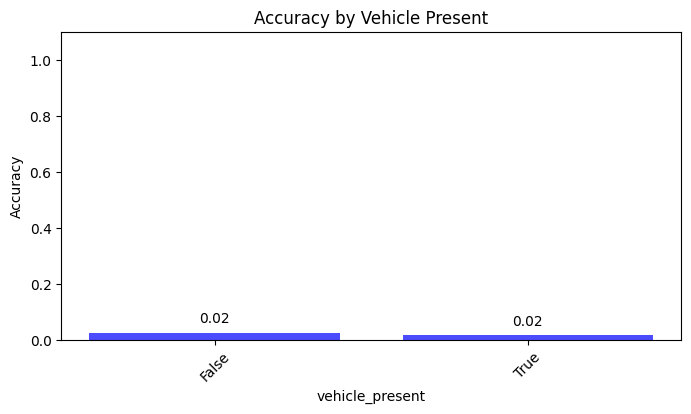

In [110]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)


### Precision


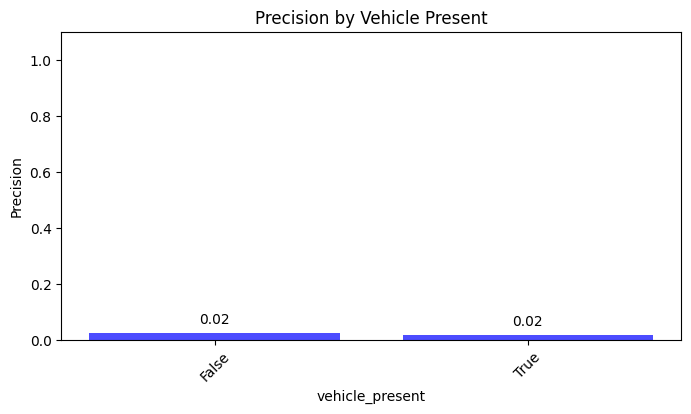

In [111]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)


### Recall


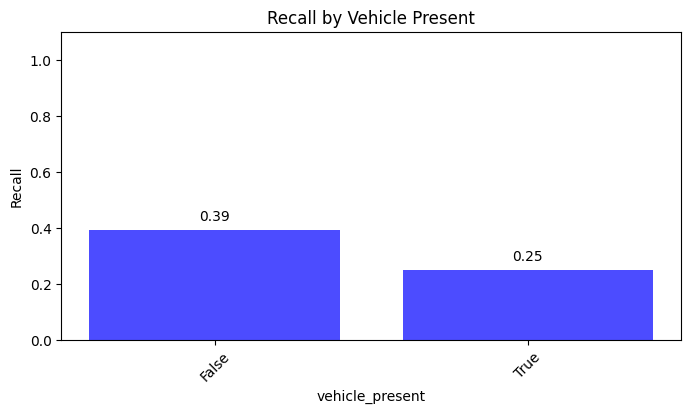

In [112]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)


### Hit Rate

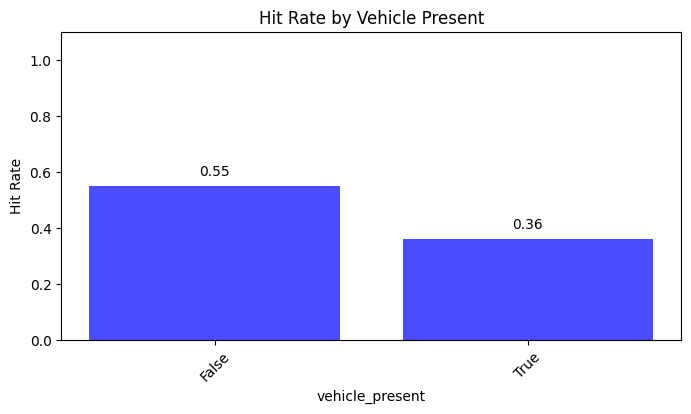

In [113]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

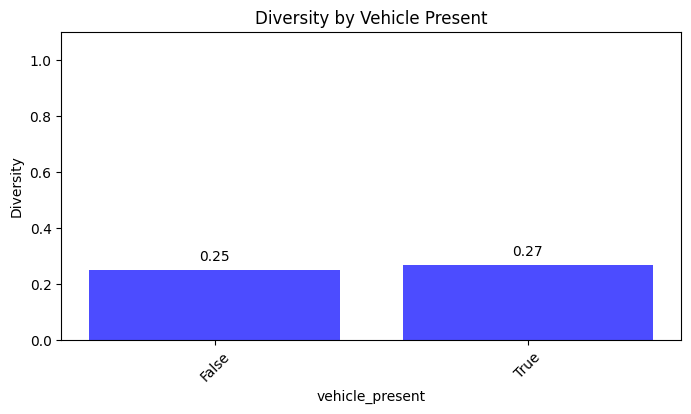

In [114]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG


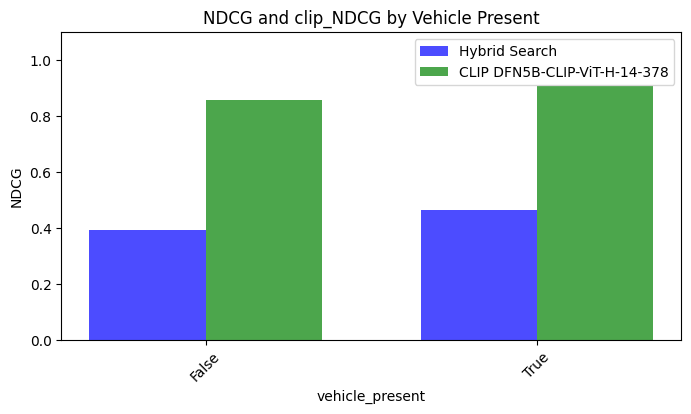

In [115]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)


### MRR


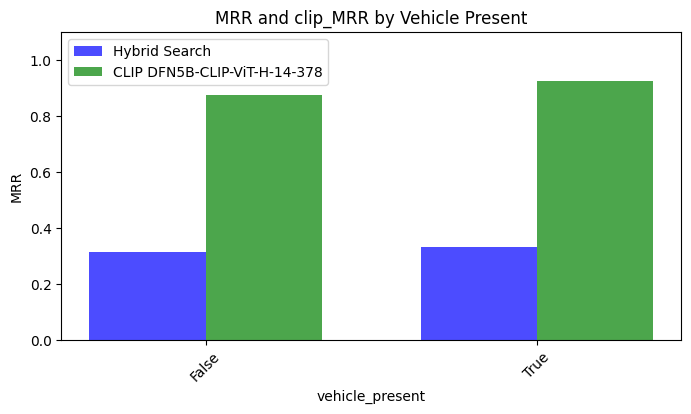

In [116]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")


## Metrics based on Lighting & Multiple Objects

Here we will group by lighting and multiple_objects and calculate the sum/mean of each metric to see how the system performs under different lighting and multiple_objects conditions.

>NOTE: due to the large number of combinations you can group by, we will not show all of them. Use this section as a guide if you want to break down the data by different combinations of the metadata.

In [117]:
# Group
light_multiple_metrics = df.groupby(['lighting', 'multiple_objects']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()
light_multiple_metrics['multiple_objects'] = light_multiple_metrics['multiple_objects'].map({True: 'True', False: 'False'})

# set up graph variables
metrics = light_multiple_metrics.rename(columns={'hit': 'hit_rate', 'rr': 'MRR', 'clip_rr': 'clip_MRR'})
x_column = 'lighting'
group_column = 'multiple_objects'
title = 'Lighting & Multiple Objects'
colors = {
    "True": "blue",
    "False": "green",
}

metrics

,lighting,multiple_objects,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,backlit,True,75,1,74,1,74,0.013333,0.013333,0.333333,0.333333,0.216847,0.666667,0.120370,0.666667,0.286777
1,bright,False,25,1,24,1,24,0.040000,0.040000,1.000000,1.000000,0.325271,1.000000,0.090909,1.000000,0.346817
2,bright,True,75,2,73,1,74,0.026667,0.013333,0.066667,0.333333,0.369490,1.000000,0.430303,1.000000,0.275335
3,day,False,250,7,243,7,243,0.028000,0.028000,0.425000,0.600000,0.415595,0.850095,0.253535,0.900000,0.216717
4,day,True,4125,91,4034,88,4037,0.022061,0.021333,0.338565,0.484848,0.419145,0.852362,0.314898,0.874805,0.264599
5,dusk,True,125,2,123,2,123,0.016000,0.016000,0.222222,0.400000,0.358544,0.666667,0.406667,0.628571,0.292543
6,indoor,False,25,0,25,0,25,0.000000,0.000000,0.000000,0.000000,0.325271,1.000000,0.043478,1.000000,0.258284
7,indoor,True,1900,52,1848,50,1850,0.027368,0.026316,0.428122,0.592105,0.405429,0.913525,0.346903,0.925439,0.258114
8,night,False,25,0,25,0,25,0.000000,0.000000,0.000000,0.000000,0.398878,1.000000,0.058824,1.000000,0.217148
9,night,True,600,8,592,8,592,0.013333,0.013333,0.195833,0.291667,0.451994,0.911784,0.351350,0.916667,0.165586


### Accuracy

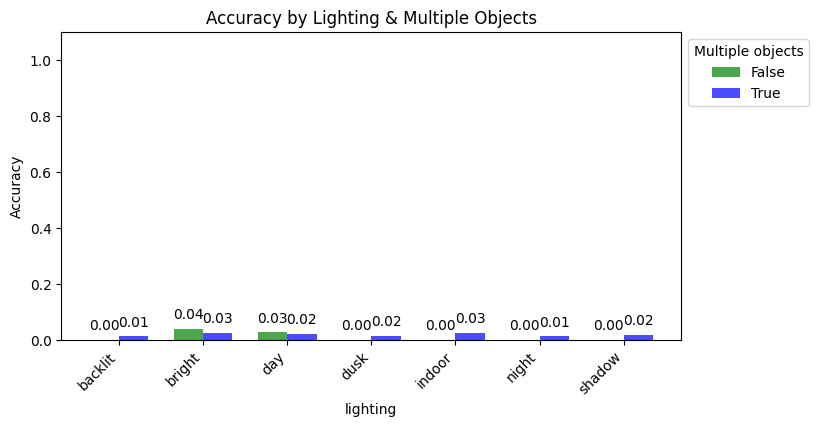

In [118]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='accuracy', 
    color_map=colors, 
    ylabel="Accuracy", 
    xlabel=x_column, 
    title=f"Accuracy by {title}",
)

### Precision

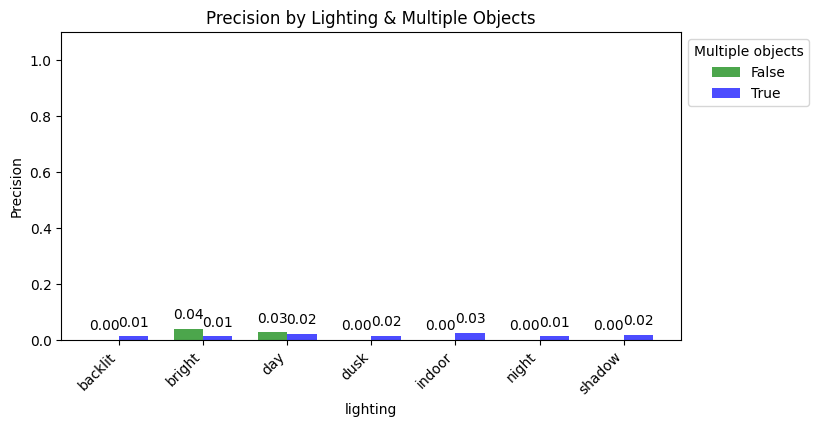

In [119]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='precision', 
    color_map=colors, 
    ylabel="Precision", 
    xlabel=x_column, 
    title=f"Precision by {title}",
)

### Recall

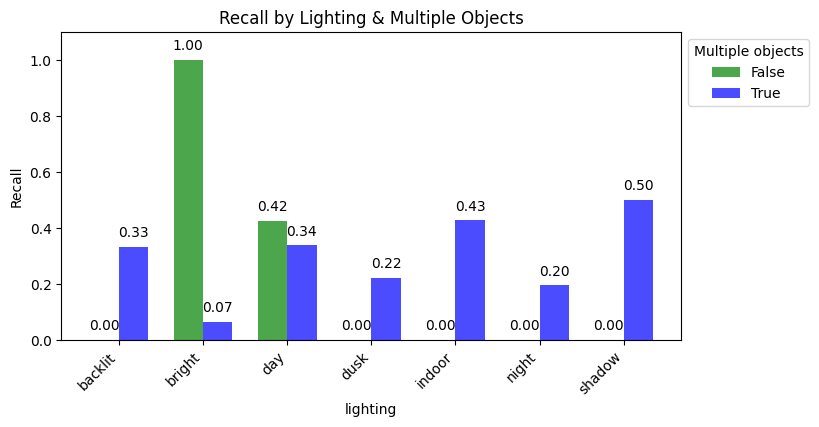

In [120]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='recall', 
    color_map=colors,
    ylabel="Recall", 
    xlabel=x_column, 
    title=f"Recall by {title}",
)

### Hit Rate

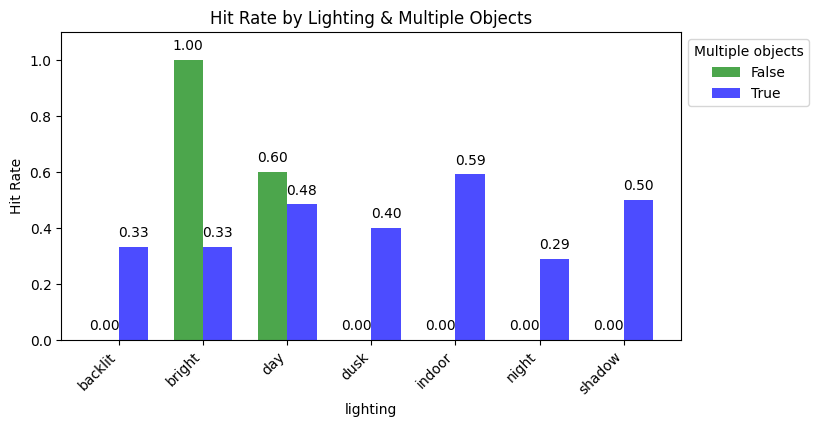

In [121]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='hit_rate', 
    color_map=colors,
    ylabel="Hit Rate", 
    xlabel=x_column, 
    title=f"Hit Rate by {title}",
)

### Diversity

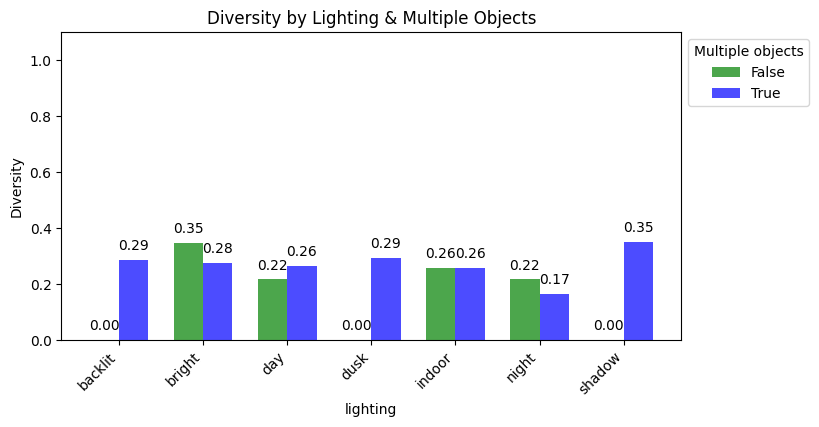

In [122]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='diversity', 
    color_map=colors,
    ylabel="Diversity", 
    xlabel=x_column, 
    title=f"Diversity by {title}",
)

### NDCG

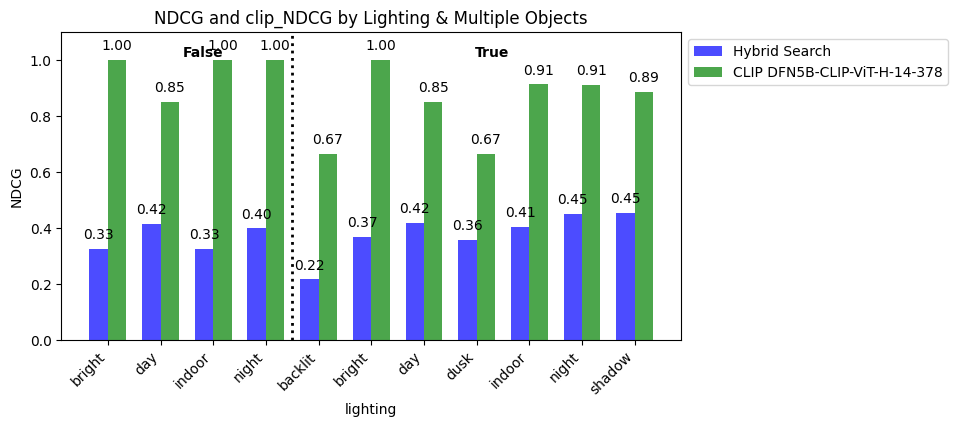

In [123]:
# Sort by group_column so group dividers and labels are correct
_ndcg_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(
    _ndcg_df,
    x_column=x_column,
    group_column=group_column,
    title=f"NDCG and clip_NDCG by {title}",
    xlabel=x_column,
)

### MRR

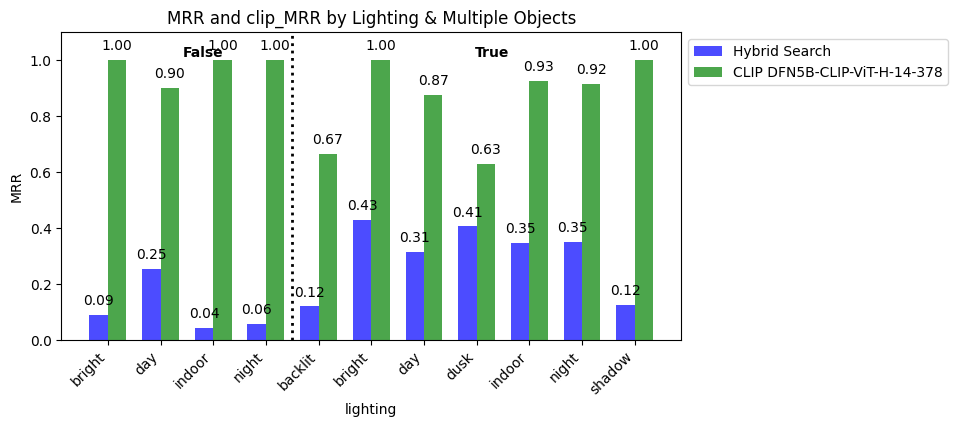

In [124]:
# Sort by group_column so group dividers and labels are correct
_mrr_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(
    _mrr_df,
    x_column=x_column,
    group_column=group_column,
    title=f"MRR and clip_MRR by {title}",
    xlabel=x_column,
    metric="MRR"
)

## Insights & Conclusion

**Main Difference**

This baseline uses **CLIP-only vector search** on Commonobjectsbench: `openai/clip-vit-base-patch32` image embeddings (`embed_image=true`, `embed_caption=false`, `index_clip_alpha=1.0`), with caption generation disabled, BM25/hybrid search off (`enable_bm25=false`, `alpha=1.0`), and `response_limit=25` to match production. No captions or keywords are indexed—retrieval depends entirely on text-to-image similarity in CLIP space for common-object queries over edge-device imagery.

---

**Overall Metrics Comparison**

| Metric                   | Baseline | 
| ------------------------ | --- | 
| **Total Images**         | 7,275 | 
| **Correctly Returned**   | 165 | 
| **Incorrectly Returned** | 7,110 | 
| **Relevant Images**      | 159 | 
| **Non-Relevant Images**  | 7,116 | 
| **Accuracy**             | 0.0227 | 
| **Precision**            | 0.0219 | 
| **Recall**               | 0.3494 | 
| **Hit Rate**             | 0.4948 | 
| **Diversity**            | 0.2546 | 
| **NDCG**                 | 0.4140 | 
| **clip_NDCG**            | 0.8713 | 
| **MRR**                  | 0.3210 | 
| **clip_MRR**             | 0.8894 | 

---

**Interpretation**

Across 7,275 returned images (291 queries × 25 results), the baseline trails **v12** on retrieval: fewer correctly returned (165 vs 203) and relevant images (159 vs 196), lower accuracy (2.3% vs 2.8%), precision (2.2% vs 2.7%), recall (34.9% vs 41.9%), and hit rate (49.5% vs 61.5%). **NDCG** is also lower (0.414 vs 0.452), while **MRR** is essentially tied (0.321 vs 0.315). **Diversity** lags v12 substantially (0.255 vs 0.355).

Both runs show a large gap between CLIP-aligned and system ranking: **clip_NDCG** (0.871) and **clip_MRR** (0.889) far exceed system **NDCG** and **MRR**, indicating the ms-marco reranker reorders results away from CLIP relevance when captions are missing (baseline) or still misaligns relative to the CLIP oracle (v12). Absolute scores remain low overall—fewer than half of queries get a relevant hit even with v12—reflecting the difficulty of fine-grained common-object retrieval in unconstrained edge imagery.

---

**Insights**

- **Caption generation and hybrid search improve retrieval on common-object queries.** v12 adds ~37 relevant images (+23%) and raises hit rate by ~12 percentage points versus CLIP-only search.
- **Recall gains are the largest relative improvement.** v12 recall (41.9%) exceeds baseline (34.9%) by ~7 pp, suggesting captions help surface more of the labeled relevant set per query.
- **Diversity benefits from the full pipeline.** Hybrid retrieval and richer indexed text produce more varied result sets (0.355 vs 0.255).
- **Reranking remains a bottleneck.** The clip_NDCG/clip_MRR vs NDCG/MRR gap on both runs points to reranker tuning as a cross-cutting improvement opportunity, especially when captions are absent.

---

**Conclusion**

On Commonobjectsbench, the CLIP-only baseline establishes a clear lower bound: sub-50% hit rate and sparse relevant retrieval. **v12's full pipeline is justified** for better coverage, recall, diversity, and NDCG, even though both versions struggle in absolute terms on this benchmark. Future work should focus on caption quality for everyday objects in edge scenes and on reranker alignment with CLIP relevance signals.

